# Setup


In [1]:
%matplotlib inline

import os, sys, warnings, math, pickle

import numpy as np
import scipy as sp
from scipy.spatial import distance
from scipy.ndimage import uniform_filter1d
from scipy import stats
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from sklearn.decomposition import PCA
import pandas as pd
import tqdm.std
sys.modules['tqdm.autonotebook'] = tqdm.std
from tqdm.std import tqdm
from tqdm.notebook import tqdm as tqdmnb
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
import torch
import torch.nn as nn

import src.utils as utils
from src.neural_network import (ModelStateManager, ModelDataManager,
                                create_rnn_and_env_for_model, run_testing, run_testing_rest,
                                infer_test_timing)
from src.utils import get_weight_masks_schaefer, get_params_dataframe, set_font_size
from src.fmri_io import global_signal_regression, select_common_subjects

import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
from src.plotting import plot_surface, _get_schaefer_annot, _roi_to_vtx
from nilearn import datasets, plotting as nilearn_plotting
from scipy.optimize import linear_sum_assignment
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from src import null_utils as nu
from scipy.stats import norm as _norm
from src.spatial_null import spin_permutations
from matplotlib.lines import Line2D


# Files and parameters


In [2]:
# directories and files
model_params_name = 'model_params_202606d'
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        modeldir = os.path.join('/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model', model_params_name)
        # modeldir = os.path.join('/Volumes/Sabrent_2TB/rutgers/neuro_rnn/data', model_params_name)
        fmridir = '/Volumes/Sabrent_2TB/rutgers/HCP/fmri'
        fmridir = '/Users/ahmad/data/rutgers/hcp'
        outdir = modeldir
elif sys.platform == 'linux':
    if username == 'ab2792':
        datadir = '/home/ab2792/software/snaplab_github/neuro_rnn/data'
        modeldir = '/home/ab2792/data/neuro_rnn/results/pytorch/model'
        outdir = modeldir
    elif username == 'lindenmp':
        datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
        modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'
        outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

model_params_file = os.path.join(datadir, model_params_name + '.csv')

check_only = False
verbose = True
save_figs = False

# select rows from model params CSV
rows_to_plot = None
rows_to_plot = [10, 11, 13]
rows_to_plot = [0, 1, 2]

# set to a specific epoch number to analyze that epoch instead of the last;
# None = use the last logged epoch for each model
analysis_epoch = 39999

model_params, task_names, n_tasks, kernel_labels, n_kernels = utils.get_params_dataframe(
    model_params_file, rows=rows_to_plot, verbose=verbose)
n_models = len(model_params)


# kernel files
sa_kernel_file = os.path.join(datadir, 'schaefer200_sa-axis.npy')
ut_kernel_file = os.path.join(datadir, 'schaefer200_ut-axis.npy')
sf_kernel_file = os.path.join(datadir, 'schaefer200_cyto.npy')
eucl_kernel_file = os.path.join(datadir, 'schaefer200_centroids.csv')

# fMRI files
tfmri_file = '/Users/ahmad/data/rutgers/hcp/hcpya_tfmri.pkl'
fmri_data_file = os.path.join(fmridir, 'HCP_YA_Schaefer2018_200Parcels_7Networks_order_Tian_Subcortex_S1_rest.npy') 
fmri_data_df_file = os.path.join(fmridir, 'HCP_YA_Schaefer2018_200Parcels_7Networks_order_Tian_Subcortex_S1_rest_df.csv') 

display(model_params)


Tasks:
------
DelayMatchSampleDistractor1D-v0
 
Kernel types:
-------------
Unmasked Reg. 
Masked Reg. 
Masked Eucl.
 
DataFrame keys:
---------------
task
seq_len_multi
time_step
alpha
rec_noise
init_hh_w
rnn_model
hidden_size
batch_size
learning_rate
n_epochs
reg_type
reg_weight
kernel_type
kernel_normalization
mask_weights
n_runs
null_perms
null_seed
null_run
null_run_ids
kernel_label
task_label
task_index
kernel_index
task_no_modifier
task_modifier
task_with_modifier
n_io
seq_len
config
file_str_models
file_str_outputs
env_kwargs
model_index
 


,task,seq_len_multi,time_step,alpha,rec_noise,init_hh_w,rnn_model,hidden_size,batch_size,learning_rate,...,task_no_modifier,task_modifier,task_with_modifier,n_io,seq_len,config,file_str_models,file_str_outputs,env_kwargs,model_index
0,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,na,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",0
1,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,14-27,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",1
2,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,14-27,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",2


# Load axes and kernels


In [3]:
hidden_size = 100

# euclidean
centroids = pd.read_csv(eucl_kernel_file)
centroids = centroids[:hidden_size]  # pull out left hemisphere
roi_names = centroids['ROI Name'].str.replace('7Networks_LH_', '')
centroids.set_index("ROI Name", inplace=True)
distance_matrix = distance.pdist(centroids, "euclidean")
distance_matrix = distance.squareform(distance_matrix)
distance_matrix_eucl = utils.normalize_x(distance_matrix)

# sa axis
sa_axis = np.load(sa_kernel_file)
sa_axis = sa_axis[:hidden_size]
distance_matrix = utils.get_brainmap_distance(brain_map=sa_axis)
distance_matrix_sa = utils.normalize_x(distance_matrix)

# ut axis
ut_axis = np.load(ut_kernel_file)
ut_axis = ut_axis[:hidden_size]
distance_matrix = utils.get_brainmap_distance(brain_map=ut_axis)
distance_matrix_ut = utils.normalize_x(distance_matrix)

# sf axis
sf_axis = np.load(sf_kernel_file)
sf_axis = sf_axis[:hidden_size]
distance_matrix = utils.get_brainmap_distance(brain_map=sf_axis)
distance_matrix_sf = utils.normalize_x(distance_matrix)

# node groups (input / internal / output)
n_io = utils.get_n_io(mask_weights=True, hidden_size=hidden_size)
n_nodes_in = int(n_io.split('-')[0])
n_nodes_out = int(n_io.split('-')[1])
n_nodes_inter = hidden_size - n_nodes_in - n_nodes_out
n_nodes = n_nodes_in + n_nodes_inter + n_nodes_out

node_groups = np.concatenate((np.ones((n_nodes_in,)) * 0,
                              np.ones((n_nodes_inter,)) * 1,
                              np.ones((n_nodes_out,)) * 2), axis=0)
node_groups_labels = ['in' if v == 0 else 'inter' if v == 1 else 'out' for v in node_groups]

# node colors
col_input = np.array([228, 149, 145]) / 255
col_bys = np.array([129, 223, 180]) / 255
col_output = np.array([122, 139, 165]) / 255
colors = np.concatenate((np.tile(col_input, [n_nodes_in, 1]),
                         np.tile(col_bys, [n_nodes_inter, 1]),
                         np.tile(col_output, [n_nodes_out, 1])), axis=0)
colors_categ = np.unique(colors, axis=0)

print(f'Node groups: {n_nodes_in} input, {n_nodes_inter} internal, {n_nodes_out} output')


Node groups: 14 input, 59 internal, 27 output


# Helper functions


In [4]:
def compute_ac_acw_aca(ts, nlags=None, fit=False, threshold_0=0.0):
    """Calculate the signal autocorrelation (lagged correlation).

    Parameters
    ----------
    ts : np.array (n_timepoints,)
        Time series.
    nlags : int (default=None)
        Number of lags to compute acf over.
    fit : bool (default=False)
        If True, fit an exponential decay to the raw ACF and use the fitted
        curve to compute acw/aca metrics instead of the raw ACF values.
    threshold_0 : float (default=0.0)
        Threshold for acw_0/aca_0 computation. Useful when AC approaches but
        does not cross zero.

    Returns
    -------
    ac : np.array (n_lags,)
        Time lagged (auto)correlation. If fit=True, returns the fitted
        exponential curve instead of the raw ACF.
    acw_50 : int
        Lag at which AC drops below 0.5. len(ac) if threshold never reached.
    acw_0 : int
        Lag at which AC drops below threshold_0. len(ac) if threshold never reached.
    aca_50 : float
        Area under the AC curve up until acw_50. len(ac) if threshold never reached.
    aca_0 : float
        Area under the AC curve up until acw_0. len(ac) if threshold never reached.
    """
    # compute auto correlation function using statsmodels
    ac = acf(ts, nlags=nlags)[:-1]
    n = len(ac)

    if fit:
        lags = np.arange(n)
        try:
            popt, _ = curve_fit(utils.exp_decay, lags, ac, p0=[10, 1], maxfev=5000)
            ac = utils.exp_decay(lags, *popt)
        except RuntimeError:
            pass  # fitting failed; fall back to raw ACF

    # get data for the 50% point
    if np.any(ac < 0.5):
        ac_trim_50 = ac[:np.where(ac < 0.5)[0][0]]
        acw_50 = ac_trim_50.shape[0]
        aca_50 = ac_trim_50.sum(axis=0)
    else:
        acw_50 = n
        aca_50 = ac.sum(axis=0)

    # get data for the 0 point
    if np.any(ac < threshold_0):
        ac_trim_0 = ac[:np.where(ac < threshold_0)[0][0]]
        acw_0 = ac_trim_0.shape[0]
        aca_0 = ac_trim_0.sum(axis=0)
    else:
        acw_0 = n
        aca_0 = ac.sum(axis=0)

    return ac, acw_50, acw_0, aca_50, aca_0


In [5]:
def compute_task_variance(hidden_activity, mask=None):
    """Compute task, temporal, and spatial variance of hidden activity.

    Parameters
    ----------
    hidden_activity : np.array (n_trials, n_timepoints, n_nodes)
        Hidden activity across trials.
    mask : np.array (n_nodes,), optional
        Boolean mask to select a subset of nodes.

    Returns
    -------
    outputs : dict
        Dictionary with keys: hidden_activity_task_var, hidden_activity_temp_var,
        hidden_activity_spat_var, hidden_activity_mean.
    """
    if mask is not None:
        hidden_activity = hidden_activity[:, :, mask]

    outputs = dict()
    outputs['hidden_activity_task_var'] = hidden_activity.var(axis=0)
    outputs['hidden_activity_temp_var'] = hidden_activity.var(axis=1)
    outputs['hidden_activity_spat_var'] = hidden_activity.var(axis=2)
    outputs['hidden_activity_mean'] = hidden_activity.mean(axis=0)

    return outputs


In [6]:
def categorical_kde_plot(df, variable, category, category_order=None, horizontal=False,
                        rug=True, color_palette=None, title=None, refline=None, ttest=False):
    """Draw a categorical KDE plot."""
    if category_order is None:
        categories = list(df[category].unique())
    else:
        categories = category_order[:]

    figsize = (5, 1 * len(categories))

    fig, axes = plt.subplots(
        nrows=len(categories) if horizontal else 1,
        ncols=1 if horizontal else len(categories),
        figsize=figsize[::-1] if not horizontal else figsize,
        sharex=horizontal,
        sharey=not horizontal,
    )
    if len(categories) == 1:
        axes = [axes]

    for i, (cat, ax) in enumerate(zip(categories, axes)):
        plot_data = df[df[category] == cat]
        if ttest:
            t_stat, p_val = stats.ttest_1samp(plot_data[variable].dropna(), refline if refline is not None else 0)
            if p_val < 0.001:
                stars = '***'
            elif p_val < 0.01:
                stars = '**'
            elif p_val < 0.05:
                stars = '*'
            else:
                stars = ''
            label = f"{cat} {stars}" if stars else cat
            print(f"{cat}: t = {t_stat:.2f}, p = {p_val:.2e}")
        else:
            label = cat
        sns.kdeplot(data=plot_data, ax=ax,
                    x=variable if horizontal else None,
                    y=None if horizontal else variable,
                    color=color_palette[i] if color_palette is not None else "lightslategray",
                    bw_adjust=1, clip_on=False, fill=True, alpha=1, linewidth=1)
        ax.axvline(x=plot_data[variable].mean(), ymax=0.5, color='lightslategray')

        if rug:
            sns.rugplot(data=df[df[category] == cat],
                        x=variable if horizontal else None,
                        y=None if horizontal else variable,
                        ax=ax, color="white", height=0.15, linewidth=0.5)

        keep_variable_axis = (i == len(fig.axes) - 1) if horizontal else (i == 0)
        # format axis
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis='both', which='major', pad=0)
        if horizontal:
            ax.set_ylabel(None)
            lim = ax.get_ylim()
            ax.set_yticks([(lim[0] + lim[1]) / 2])
            ax.set_yticklabels([label])
            if not keep_variable_axis:
                ax.get_xaxis().set_visible(False)
                ax.spines["bottom"].set_visible(False)
        else:
            ax.set_xlabel(None)
            lim = ax.get_xlim()
            ax.set_xticks([(lim[0] + lim[1]) / 2])
            ax.set_xticklabels([label])
            if not keep_variable_axis:
                ax.get_yaxis().set_visible(False)
                ax.spines["left"].set_visible(False)
                
        if refline is not None:
            if horizontal:
                ax.axvline(x=refline, color=[0.5]*3, linestyle='--')
            else:
                ax.axhline(y=refline, color=[0.5]*3, linestyle='--')
    
    if title is not None:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()
    return fig


In [7]:
def fit_pca(data, n_components=3):
    """Perform PCA on time series data.

    Parameters
    ----------
    data : np.ndarray or list
        Time series array of shape [time, nodes], or 
        list of trial data where each trial has shape [time, nodes].
    n_components : int
        Number of principal components to retain.
        
    Note: when ``data`` is a list of trials, it is converted to one array
    before PCA fitting, rather than performing a per-trial PCA. 

    Returns
    -------
    pca : sklearn.decomposition.PCA
        Fitted PCA object. Uses sklearn's internal centering, so
        ``pca.mean_`` holds the per-feature mean of the fit data.
    data_pc : np.ndarray or list of np.ndarray
        Input data projected into PC space. If ``data`` was a list of
        trials, returns a list of arrays each of shape
        [n_timepoints, n_components], one per trial. Otherwise returns
        a single array of shape [n_timepoints, n_components].
    n_trials : int or None
        Number of trials if ``data`` was a list, otherwise None.
    n_timepoints : int or None
        Number of time points per trial if ``data`` was a list,
        otherwise None.
    n_nodes : int
        Number of features (nodes) in the input data.
    variance_explained : dict
        Fraction of total variance captured by the retained components:
        - 'each': np.ndarray of shape (n_components,), per-component
          variance ratio.
        - 'cumul': np.ndarray of shape (n_components,), cumulative
          variance ratio.
        - 'total': float, sum of per-component variance ratios
          (i.e., total variance captured by all retained components).
    """
    
    input_is_list = isinstance(data, list)
    
    if input_is_list:
        n_trials = len(data)
        n_timepoints, n_nodes = data[0].shape
        data_mat = np.reshape(np.array(data),
                              (n_trials * n_timepoints, n_nodes))
    else:
        n_trials = None
        n_timepoints = None
        n_nodes = data.shape[1]
        data_mat = data

    pca = PCA(n_components=n_components)
    pca.fit(data_mat)

    variance_explained = {
        'each': pca.explained_variance_ratio_,
        'cumul': np.cumsum(pca.explained_variance_ratio_),
        'total': np.sum(pca.explained_variance_ratio_)
    }

    if input_is_list:
        data_pc = [pca.transform(trial) for trial in data]
    else:
        data_pc = pca.transform(data)

    return pca, data_pc, n_trials, n_timepoints, n_nodes, variance_explained


def pca_projection(data, pca_fitted, centering_mean='data'):
    """Project time series data into PC space.
    
    Parameters
    ----------
    data : np.ndarray or list
        Time series array of shape [time, nodes], or 
        list of trial data where each trial has shape [time, nodes].
    pca_fitted : PCA object
        Pre-fitted PCA object from sklearn.
    centering_mean : str
        - 'data': input data is centered using its own means. Use this when 
          projecting across vastly different datasets, e.g., fMRI into RNN PC space.
        - 'pca': input data is centered using ``pca_fitted.mean_``. Use this when 
          the input data is matched to the one used to fit the PCA model, 
          e.g., projecting data from an RNN model into its own PC space.
         
        Note: when ``data`` is a list of trials, centering under 'data' mode
        uses the global mean across all concatenated trials, not a per-trial
        mean. This preserves across-trial variance in the projection.
        
    Returns
    -------
    data_pc : np.ndarray or list of np.ndarray
        Input data projected into PC space. If ``data`` was a list of
        trials, returns a list of arrays each of shape
        [n_timepoints, n_components]. Otherwise returns a single array
        of shape [n_timepoints, n_components].
    variance_explained : dict
        - 'each': per-component variance ratio, shape (n_components,).
        - 'cumul': cumulative variance ratio, shape (n_components,).
        - 'total': float, sum across retained components.
    
    """
    
    input_is_list = isinstance(data, list)
    
    if input_is_list:
        n_trials = len(data)
        n_timepoints, n_nodes = data[0].shape
        data_mat = np.reshape(np.array(data),
                              (n_trials * n_timepoints, n_nodes))
    else:
        data_mat = np.asanyarray(data)
    
    if data_mat.ndim != 2:
        raise ValueError("Input data must be 2D array with shape [time, nodes] or list of such arrays")

    n_nodes = data_mat.shape[1]
    expected_nodes = pca_fitted.n_features_in_

    if n_nodes != expected_nodes:
        raise ValueError(f"Input data has {n_nodes} nodes, but PCA was fitted on {expected_nodes} nodes")

    if centering_mean == 'data':
        data_mat = data_mat - np.mean(data_mat, axis=0)
    elif centering_mean == 'pca':
        data_mat = data_mat - pca_fitted.mean_
    else:
        raise ValueError(f"centering_mean must be 'data' or 'pca', got {centering_mean!r}")

    data_pc = data_mat @ pca_fitted.components_.T

    # calculate variance explained
    total_variance = np.sum(np.power(data_mat, 2), axis=None)
    pc_variances = np.sum(np.power(data_pc, 2), axis=0)
    variance_explained_each = pc_variances / total_variance

    variance_explained = {
        'each': variance_explained_each,
        'cumul': np.cumsum(variance_explained_each),
        'total': np.sum(variance_explained_each)
    }
    
    if input_is_list:
        n_components = data_pc.shape[1]
        data_pc = list(data_pc.reshape(n_trials, n_timepoints, n_components))

    return data_pc, variance_explained


In [8]:
# set_font_size is imported from src.utils
font_size = 11

In [9]:
def sig_indicator(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# Load trained models


In [10]:
device = torch.device('cpu')

if check_only:

    found_count = 0
    for model_idx in range(n_models):
        this = model_params.iloc[model_idx]
        file_path_models = os.path.join(modeldir, this.file_str_models)
        file_path_outputs = os.path.join(modeldir, this.file_str_outputs)
        if os.path.isfile(file_path_models):
            found_count += 1
        else:
            print(f'Not found ... {this.file_str_models} ({model_idx})')
    print(f'Found {found_count}/{n_models} files.')

else:

    trained_models_all = []
    model_accuracy_all = []

    for model_idx in tqdm(range(n_models), desc='Loading data'):

        this = model_params.iloc[model_idx]
        utils.check_if_supported(task=this.task_no_modifier, modifier=this.task_modifier)

        file_path_models = os.path.join(modeldir, this.file_str_models)
        file_path_outputs = os.path.join(modeldir, this.file_str_outputs)

        # remove delay variability for testing
        if 'delay' in this['env_kwargs']['timing']:
            d, _ = utils.parse_task_modifier(this.task_modifier)
            try:
                this['env_kwargs']['timing']['delay'] = d[0]
            except:
                pass

        # get model info
        state_manager = ModelStateManager(file_path_models)
        n_runs, logged_epochs, keys_per_epoch = state_manager.get_info()
        n_runs = np.min((n_runs, 100))

        # select epoch: use analysis_epoch if set and available, otherwise last
        if analysis_epoch is not None:
            if analysis_epoch in logged_epochs:
                use_epoch = analysis_epoch
            else:
                # pick the nearest available epoch
                use_epoch = logged_epochs[np.argmin(np.abs(np.array(logged_epochs) - analysis_epoch))]
                print(f'  Model {model_idx}: epoch {analysis_epoch} not found, using nearest: {use_epoch}')
        else:
            use_epoch = logged_epochs[-1]

        # create rnn and dataset for each trained run
        trained_models = []
        for run in range(n_runs):
            dataset, rnn = create_rnn_and_env_for_model(this,
                                                         run=run,
                                                         epoch=use_epoch,
                                                         data_dir=modeldir,
                                                         device=device)
            trained_models.append({'dataset': dataset, 'rnn': rnn})
        trained_models_all.append(trained_models)


Loading data: 100%|██████████| 3/3 [00:06<00:00,  2.23s/it]


# Load fMRI data

In [11]:
n_fmri_subj = 100
pick_random_subjects = True

## Load task and rest fMRI data and get unified subject list

In [12]:
# Load task fMRI data and get subject list
with open(tfmri_file, 'rb') as f:
    tfmri = pickle.load(f)
fmri_task_key = 'tfMRIWMLR'
fmri_task_parc = 'Schaefer2007'
fmri_task_subjnames = list(tfmri.keys())
print(f'fMRI task N subjects: {len(fmri_task_subjnames)}')

fMRI task N subjects: 962


In [13]:
# Load resting state fMRI data and get subject list
fmri_rest_data_df = pd.read_csv(fmri_data_df_file)
use_fmri_rest = pd.concat((fmri_rest_data_df.rfMRI_available,
                      fmri_rest_data_df.rfMRI_REST1_LR,
                      fmri_rest_data_df.rfMRI_REST1_RL,
                      fmri_rest_data_df.rfMRI_REST2_LR,
                      fmri_rest_data_df.rfMRI_REST2_RL),
                     axis=1).to_numpy()
use_fmri_rest = np.all(use_fmri_rest,axis=1)
fmri_rest_data_df = fmri_rest_data_df.iloc[use_fmri_rest]
fmri_rest_subjnames = [str(x) for x in fmri_rest_data_df.Subject]
fmri_rest_data = np.load(fmri_data_file)
fmri_rest_data = fmri_rest_data[:,16:116,0,use_fmri_rest]
print(f'fMRI rest N subjects: {len(fmri_rest_subjnames)}')

fMRI rest N subjects: 1086


In [14]:
# Select N common subjects.
# Use the SAME seeded selection as biornn_results_dynamics_trajectory.py
# (np.random.default_rng(seed=42)) so both notebooks use the identical subject
# set -- required for the trajectory nb's chance normalization to align per
# subject with the VE arrays computed here.
subject_seed = 42
fmri_subjnames = select_common_subjects(fmri_task_subjnames, fmri_rest_subjnames,
                                        n_fmri_subj, seed=subject_seed,
                                        pick_random=pick_random_subjects)
fmri_task_subjbool = [fmri_task_subjnames[ind] in fmri_subjnames for ind in range(len(fmri_task_subjnames))]
fmri_rest_subjbool = [fmri_rest_subjnames[ind] in fmri_subjnames for ind in range(len(fmri_rest_subjnames))]
fmri_task_nsubj = n_fmri_subj
fmri_rest_nsubj = n_fmri_subj
fmri_subjnames

[np.str_('198350'),
 np.str_('871762'),
 np.str_('436239'),
 np.str_('200917'),
 np.str_('195041'),
 np.str_('573249'),
 np.str_('132017'),
 np.str_('169444'),
 np.str_('134324'),
 np.str_('432332'),
 np.str_('136631'),
 np.str_('208125'),
 np.str_('188347'),
 np.str_('598568'),
 np.str_('179245'),
 np.str_('392750'),
 np.str_('698168'),
 np.str_('139435'),
 np.str_('705341'),
 np.str_('882161'),
 np.str_('146836'),
 np.str_('810843'),
 np.str_('735148'),
 np.str_('126325'),
 np.str_('134728'),
 np.str_('611938'),
 np.str_('615744'),
 np.str_('139637'),
 np.str_('559053'),
 np.str_('130720'),
 np.str_('152225'),
 np.str_('227432'),
 np.str_('513736'),
 np.str_('209127'),
 np.str_('214221'),
 np.str_('162228'),
 np.str_('788876'),
 np.str_('555954'),
 np.str_('342129'),
 np.str_('594156'),
 np.str_('878877'),
 np.str_('723141'),
 np.str_('237334'),
 np.str_('187345'),
 np.str_('193239'),
 np.str_('205826'),
 np.str_('381543'),
 np.str_('114217'),
 np.str_('518746'),
 np.str_('148941'),


In [15]:
# Select corresponding task data
fmri_task_nsteps = np.min([tfmri[fmri_subjnames[i]][fmri_task_parc][fmri_task_key].shape[0]
                       for i in range(n_fmri_subj)])
fmri_task_ts = np.zeros((fmri_task_nsteps, n_nodes, fmri_task_nsubj))

for i in range(n_fmri_subj):
    # xxx = tfmri[fmri_subjnames[i]][fmri_task_parc][fmri_task_key][:fmri_task_nsteps, :n_nodes]
    # fmri_task_ts[:, :, i] = xxx - np.mean(xxx, axis=0)
    fmri_task_ts[:, :, i] =  tfmri[fmri_subjnames[i]][fmri_task_parc][fmri_task_key][:fmri_task_nsteps, :n_nodes]
print(f'fMRI task shape (time, nodes, subjects): {fmri_task_ts.shape}')

# Select corresponding rest data
fmri_rest_ts = fmri_rest_data[:, :, fmri_rest_subjbool]
fmri_rest_nsteps = fmri_rest_ts.shape[0]
print(f'fMRI rest shape (time, nodes, subjects): {fmri_rest_ts.shape}')

fMRI task shape (time, nodes, subjects): (405, 100, 100)
fMRI rest shape (time, nodes, subjects): (1200, 100, 100)


In [16]:
# Perform GSR on loaded fMRI data.
# For each subject, regress the global signal (mean across nodes at each timepoint)
# out of each node's time series using OLS.
apply_gsr = True

# global_signal_regression is imported from src.fmri_io
if apply_gsr:
    fmri_task_ts = global_signal_regression(fmri_task_ts)
    fmri_rest_ts = global_signal_regression(fmri_rest_ts)
    print(f'GSR applied to task ({fmri_task_ts.shape}) and rest ({fmri_rest_ts.shape}) fMRI data.')
else:
    print('GSR skipped.')

GSR applied to task ((405, 100, 100)) and rest ((1200, 100, 100)) fMRI data.


# Load Euclidean distance mats

In [17]:
dist_file = '/Users/ahmad/data/rutgers/hcp/HCP_YA_Coords_Schaefer2018_200Parcels_7Networks.npz'
loaded = np.load(dist_file)
data = {k: loaded[k] for k in loaded.files}
eucl_dist_all = {}
for k in fmri_subjnames: # data.keys():
    x = data[k][:hidden_size]
    eucl_dist_all[k] = distance.cdist(x,x)
print(f'Loaded Euclidean distance mats {eucl_dist_all[k].shape} for {len(eucl_dist_all)} subjects.')


Loaded Euclidean distance mats (100, 100) for 100 subjects.


# Test models


In [18]:
# define number of test trials
n_trials = 100

# define window size for smoothing of noise input during resting state testing
smooth_noise = 0

def test_one_model(model_data, n_trials, smooth_noise):
    torch.set_num_threads(1)  # prevent thread contention across parallel workers

    test_model_task = []
    test_model_rest = []

    for run in range(len(model_data)):
        dataset = model_data[run]['dataset']
        rnn = model_data[run]['rnn']

        # test on task trials
        accuracy, inputs, labels, hidden_activity, output_activity, info = run_testing(
            dataset=dataset, model=rnn, n_trials=n_trials, verbose=False)
        test_model_task.append({
            'accuracy': accuracy,
            'inputs': inputs,
            'labels': labels,
            'hidden_activity': hidden_activity,
            'output_activity': output_activity,
            'info': info
        })

        # test on noise inputs (resting state)
        inputs_rest, hidden_activity_rest, output_activity_rest = run_testing_rest(
            rnn, smooth_noise=smooth_noise, noise_mean=0.5, noise_sd=0.3,
            n_steps=fmri_rest_nsteps, fix_input_channels=[])
        test_model_rest.append({
            'inputs': inputs_rest,
            'hidden_activity': hidden_activity_rest,
            'output_activity': output_activity_rest
        })

    return test_model_task, test_model_rest

with tqdm_joblib(tqdm(total=n_models, disable=True), desc='Testing models', gui=False):
    results = Parallel(n_jobs=-1)(
        delayed(test_one_model)(trained_models_all[model_idx], n_trials, smooth_noise)
        for model_idx in range(n_models)
    )

test_data_task = [r[0] for r in results]
test_data_rest = [r[1] for r in results]

Testing models:   0%|          | 0/3 [00:00<?, ?it/s]/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.timing to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.timing` for environment variables or `env.get_wrapper_attr('timing')` that will search the reminding wrappers.
  logger.warn(
/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.sample_time to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.sample_time` for environment variables or `env.get_wrapper_attr('sample_time')` that will search the reminding wrappers.
  logger.warn(
/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrapp

# PCA analysis


## Set number of PCs

In [19]:
n_pc = 5

## Run PCA on trained models

In [20]:
pca_hidden_task = list()
pca_hidden_rest = list()
test_accuracy_pca = list()

for model_idx in range(n_models):
    pca_hidden_task_model = list()
    pca_hidden_rest_model = list()
    n_runs = len(test_data_task[model_idx])
    test_accuracy_model = np.zeros((n_runs))
    this = model_params.iloc[model_idx]
    print(f"{this.task_no_modifier} -- {this.kernel_label}")
    ve_task = np.zeros((n_runs, 1))
    ve_rest = np.zeros((n_runs, 1))

    for run_idx in tqdm(range(n_runs), desc=f'Model {model_idx+1}/{n_models}'):
        
        # task PCA
        pca, hpc, nt, ntp, nn, var_exp = fit_pca(
            data=test_data_task[model_idx][run_idx]['hidden_activity'], 
            n_components=n_pc)

        trial_categ = test_data_task[model_idx][run_idx]['info'].ground_truth.to_numpy()
        categs = np.unique(trial_categ)
        pca_by_categ = dict()
        for c in categs:
            pc_sum = np.zeros((ntp, n_pc))
            n_t = 0
            for t in range(nt):
                if trial_categ[t] == c:
                    pc_sum += hpc[t]
                    n_t += 1
            pca_by_categ[str(c)] = pc_sum / n_t

        run_accuracy = test_data_task[model_idx][run_idx]['accuracy']
        test_accuracy_model[run_idx] = run_accuracy
        pca_hidden_task_model.append({
            'pca': pca,
            'hidden_pc': hpc,
            'n_trials': nt,
            'n_time_points': ntp,
            'n_nodes': nn,
            'var_exp': var_exp,
            'hidden_pc_categ': pca_by_categ,
            'accuracy': run_accuracy
        })
        ve_task[run_idx] = var_exp['total']
        
        # rest PCA
        pca, hpc, nt, ntp, nn, var_exp = fit_pca(
            data=test_data_rest[model_idx][run_idx]['hidden_activity'],
            n_components=n_pc)
        
        pca_hidden_rest_model.append({
            'pca': pca,
            'hidden_pc': hpc,
            'n_time_points': ntp,
            'n_nodes': nn,
            'var_exp': var_exp
        })
        ve_rest[run_idx] = var_exp['total']

    pca_hidden_task.append(pca_hidden_task_model)
    pca_hidden_rest.append(pca_hidden_rest_model)
    test_accuracy_pca.append(test_accuracy_model)
    print(f'Mean variance explained (task): {ve_task.mean()*100:.2f}%')
    print(f'Mean variance explained (rest): {ve_rest.mean()*100:.2f}%')
    print(' ')


DelayMatchSampleDistractor1D-v0 -- Unmasked Reg. 


Model 1/3: 100%|██████████| 100/100 [00:00<00:00, 149.36it/s]


Mean variance explained (task): 72.67%
Mean variance explained (rest): 87.27%
 
DelayMatchSampleDistractor1D-v0 -- Masked Reg. 


Model 2/3: 100%|██████████| 100/100 [00:00<00:00, 150.37it/s]


Mean variance explained (task): 77.22%
Mean variance explained (rest): 90.22%
 
DelayMatchSampleDistractor1D-v0 -- Masked Eucl.


Model 3/3: 100%|██████████| 100/100 [00:00<00:00, 151.44it/s]

Mean variance explained (task): 76.18%
Mean variance explained (rest): 88.13%
 


## Run PCA on task fMRI


100%|██████████| 100/100 [00:00<00:00, 355.60it/s]


Median within-subject variance explained (task): 53.91%


100%|██████████| 100/100 [00:01<00:00, 74.16it/s]


Median between-subject variance explained (task): 27.33%


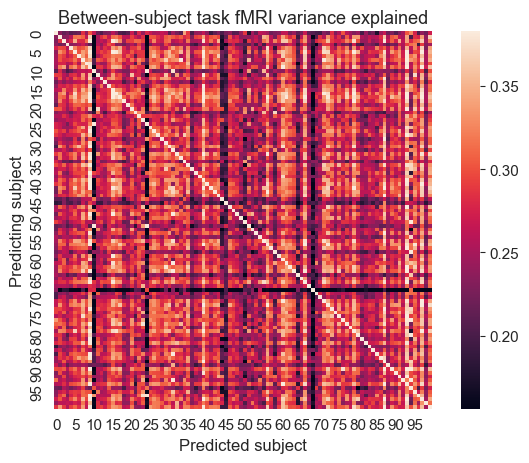

In [21]:
pca_fmri_task = list()
pca_fmri_task_var_exp = np.zeros((n_fmri_subj,))

for si in tqdm(range(n_fmri_subj)):
    this_fmri = fmri_task_ts[:, :, si]
    pca, _, _, _, _, variance_explained = fit_pca(data=this_fmri, n_components=n_pc)
    pca_fmri_task.append({'pca': pca, 'var_exp': variance_explained})
    pca_fmri_task_var_exp[si] = variance_explained['total']

print(f'Median within-subject variance explained (task): {100*np.median(pca_fmri_task_var_exp):.2f}%')

# compute inter-subject variance explained (baseline)
fmri_task_intersubj_var_exp_all = np.zeros((n_fmri_subj, n_fmri_subj))
for s1 in tqdm(range(n_fmri_subj)):
    pca1 = pca_fmri_task[s1]['pca']
    for s2 in range(n_fmri_subj):
        ts2 = fmri_task_ts[:, :, s2]
        _, variance_explained = pca_projection(ts2, pca1, centering_mean='data')
        fmri_task_intersubj_var_exp_all[s1, s2] = variance_explained['total']
triuind = np.triu_indices_from(fmri_task_intersubj_var_exp_all, k=1)
fmri_task_intersubj_var_exp_all_vec = fmri_task_intersubj_var_exp_all[triuind]
fmri_task_intersubj_var_exp = np.median(fmri_task_intersubj_var_exp_all_vec)
print(f'Median between-subject variance explained (task): {100*fmri_task_intersubj_var_exp:.2f}%')

set_font_size(12)
plt.figure()
sns.heatmap(fmri_task_intersubj_var_exp_all, robust=True, square=True)
plt.xlabel('Predicted subject')
plt.ylabel('Predicting subject')
plt.title('Between-subject task fMRI variance explained')
plt.tight_layout()
plt.show()

## Run PCA on resting state fMRI


100%|██████████| 100/100 [00:00<00:00, 1071.39it/s]


Median within-subject variance explained (rest): 38.95%


100%|██████████| 100/100 [00:01<00:00, 59.75it/s]


Median between-subject variance explained (rest): 26.90%
Unified inter-subject baseline (mean of task+rest): 27.11%


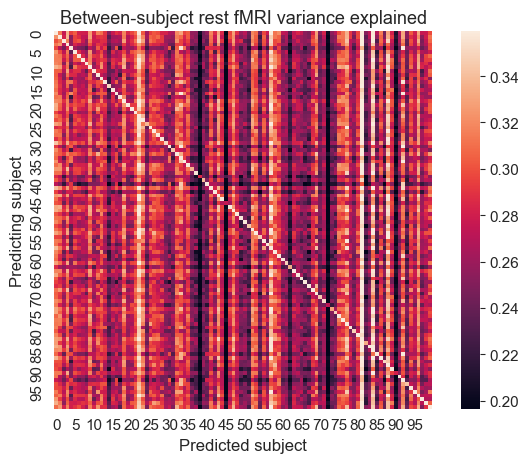

In [22]:
pca_fmri_rest = list()
pca_fmri_rest_var_exp = np.zeros((n_fmri_subj,))

for si in tqdm(range(n_fmri_subj)):
    this_fmri = fmri_rest_ts[:, :, si]
    pca, _, _, _, _, variance_explained = fit_pca(data=this_fmri, n_components=n_pc)
    pca_fmri_rest.append({'pca': pca, 'var_exp': variance_explained})
    pca_fmri_rest_var_exp[si] = variance_explained['total']

print(f'Median within-subject variance explained (rest): {100*np.median(pca_fmri_rest_var_exp):.2f}%')

# compute inter-subject variance explained (baseline)
N = n_fmri_subj
fmri_rest_intersubj_var_exp_all = np.zeros((N, N))
for s1 in tqdm(range(N)):
    pca1 = pca_fmri_rest[s1]['pca']
    for s2 in range(N):
        ts2 = fmri_rest_ts[:, :, s2]
        _, variance_explained = pca_projection(ts2, pca1, centering_mean='data')
        fmri_rest_intersubj_var_exp_all[s1, s2] = variance_explained['total']
triuind = np.triu_indices_from(fmri_rest_intersubj_var_exp_all, k=1)
fmri_rest_intersubj_var_exp_all_vec = fmri_rest_intersubj_var_exp_all[triuind]
fmri_rest_intersubj_var_exp = np.median(fmri_rest_intersubj_var_exp_all_vec)
print(f'Median between-subject variance explained (rest): {100*fmri_rest_intersubj_var_exp:.2f}%')

# Unified inter-subject baseline used to normalize all downstream VE values
# (matched, cross-modal, and variance-decomposition components). Defined as the
# mean of the task and rest inter-subject medians so a single divisor is used
# across modalities.
fmri_intersubj_var_exp = 0.5 * (fmri_task_intersubj_var_exp + fmri_rest_intersubj_var_exp)
print(f'Unified inter-subject baseline (mean of task+rest): {100*fmri_intersubj_var_exp:.2f}%')

set_font_size(12)
plt.figure()
sns.heatmap(fmri_rest_intersubj_var_exp_all, robust=True, square=True)
plt.xlabel('Predicted subject')
plt.ylabel('Predicting subject')
plt.title('Between-subject rest fMRI variance explained')
plt.tight_layout()
plt.show()


## Perform some additional checks on fMRI PCA results

Lowest-VE subjects (rest):
  idx= 72  subj=108323  mean_VE=0.192
  idx= 45  subj=205826  mean_VE=0.194
  idx= 38  subj=342129  mean_VE=0.198
  idx= 90  subj=189652  mean_VE=0.205
  idx= 62  subj=519950  mean_VE=0.218
  idx= 82  subj=812746  mean_VE=0.229
  idx= 51  subj=825553  mean_VE=0.232
  idx= 14  subj=179245  mean_VE=0.234
  idx= 93  subj=128127  mean_VE=0.239
  idx= 37  subj=555954  mean_VE=0.239

Lowest-VE subjects (task):
  idx= 68  subj=156233  mean_VE=0.174
  idx= 10  subj=136631  mean_VE=0.181
  idx= 24  subj=134728  mean_VE=0.184
  idx= 45  subj=205826  mean_VE=0.202
  idx= 64  subj=395958  mean_VE=0.211
  idx= 44  subj=193239  mean_VE=0.215
  idx= 50  subj=333330  mean_VE=0.222
  idx= 36  subj=788876  mean_VE=0.227
  idx= 58  subj=465852  mean_VE=0.233
  idx= 98  subj=194140  mean_VE=0.236

Overlap (rest ∩ task): 1/10 subjects
  indices: [np.int64(45)]
  subjects: [np.str_('205826')]

Spearman(rest col_means, task col_means) = -0.117, p = 2.48e-01

Rest baseline median: f

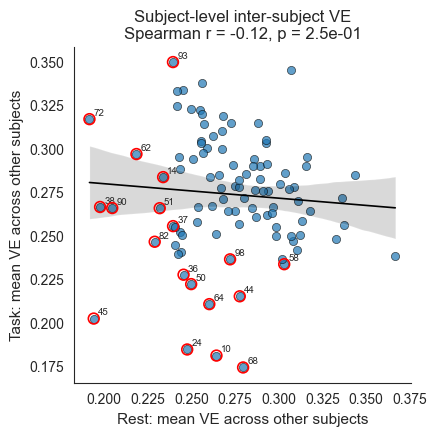

In [23]:
# Identify subjects with atypical covariance structure in the inter-subject baselines
# (dark columns in the heatmaps = variance not captured by other subjects' PCs).

n_outliers = 10

# Column means = how well each subject's data is explained, averaged across all
# other subjects' PC bases. Mask the diagonal so within-subject fits don't inflate.
def column_means_offdiag(M):
    M = M.copy()
    np.fill_diagonal(M, np.nan)
    return np.nanmean(M, axis=0)

rest_col_means = column_means_offdiag(fmri_rest_intersubj_var_exp_all)
task_col_means = column_means_offdiag(fmri_task_intersubj_var_exp_all)

rest_outliers = np.argsort(rest_col_means)[:n_outliers]
task_outliers = np.argsort(task_col_means)[:n_outliers]

print('Lowest-VE subjects (rest):')
for i in rest_outliers:
    print(f'  idx={i:3d}  subj={fmri_subjnames[i]}  mean_VE={rest_col_means[i]:.3f}')

print('\nLowest-VE subjects (task):')
for i in task_outliers:
    print(f'  idx={i:3d}  subj={fmri_subjnames[i]}  mean_VE={task_col_means[i]:.3f}')

# Overlap between rest and task outliers — is it a subject-level property or session-specific?
overlap = sorted(set(rest_outliers) & set(task_outliers))
print(f'\nOverlap (rest ∩ task): {len(overlap)}/{n_outliers} subjects')
if overlap:
    print(f'  indices: {overlap}')
    print(f'  subjects: {[fmri_subjnames[i] for i in overlap]}')

# Rank correlation between the two — does a subject's "outlierness" transfer across conditions?
rho, pval = stats.spearmanr(rest_col_means, task_col_means)
print(f'\nSpearman(rest col_means, task col_means) = {rho:.3f}, p = {pval:.2e}')

# Impact on the median baseline if we dropped the worst subjects
def median_triu(M, exclude=None):
    M = M.copy()
    if exclude is not None and len(exclude):
        keep = np.setdiff1d(np.arange(M.shape[0]), exclude)
        M = M[np.ix_(keep, keep)]
    iu = np.triu_indices_from(M, k=1)
    return np.median(M[iu])

rest_med_full = median_triu(fmri_rest_intersubj_var_exp_all)
rest_med_drop = median_triu(fmri_rest_intersubj_var_exp_all, exclude=rest_outliers)
task_med_full = median_triu(fmri_task_intersubj_var_exp_all)
task_med_drop = median_triu(fmri_task_intersubj_var_exp_all, exclude=task_outliers)

print(f'\nRest baseline median: full={rest_med_full:.4f}  '
      f'dropping {n_outliers} outliers={rest_med_drop:.4f}  '
      f'(Δ={rest_med_drop-rest_med_full:+.4f})')
print(f'Task baseline median: full={task_med_full:.4f}  '
      f'dropping {n_outliers} outliers={task_med_drop:.4f}  '
      f'(Δ={task_med_drop-task_med_full:+.4f})')

# Side-by-side scatter: task vs rest per-subject column means
set_font_size(11)
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

sns.regplot(x=rest_col_means, y=task_col_means, ax=ax,
            scatter_kws={'s': 35, 'alpha': 0.7,
                         'edgecolors': 'k', 'linewidths': 0.5},
            line_kws={'color': 'k', 'linewidth': 1.2},
            ci=95)

# highlight outliers
for i in set(rest_outliers) | set(task_outliers):
    ax.scatter(rest_col_means[i], task_col_means[i], s=60,
               facecolors='none', edgecolors='red', linewidths=1.2, zorder=5)
    ax.annotate(str(i), (rest_col_means[i], task_col_means[i]),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Rest: mean VE across other subjects')
ax.set_ylabel('Task: mean VE across other subjects')
ax.set_title(f'Subject-level inter-subject VE\nSpearman r = {rho:.2f}, p = {pval:.1e}')
sns.despine(fig=fig)
fig.tight_layout()
plt.show()



## Plot PC loadings on brain surface

DelayMatchSampleDistractor1D-v0 / Masked Eucl.: selected top 100/100 runs (W-K cosine range: 0.109 – 0.270)
DelayMatchSampleDistractor1D-v0 / Unmasked Reg.  (task): [99 99 99]/100 runs with poor PC match (cosine < 0.5); mean sim = [0.13881268 0.12309444 0.12439799]
DelayMatchSampleDistractor1D-v0 / Masked Reg.  (task): [99 99 99]/100 runs with poor PC match (cosine < 0.5); mean sim = [0.1255069  0.13304376 0.13201421]
DelayMatchSampleDistractor1D-v0 / Masked Eucl. (task): [99 99 99]/100 runs with poor PC match (cosine < 0.5); mean sim = [0.23439446 0.21032171 0.1970544 ]
DelayMatchSampleDistractor1D-v0 / Unmasked Reg.  (rest): [99 99 99]/100 runs with poor PC match (cosine < 0.5); mean sim = [0.13560057 0.13053176 0.12720312]
DelayMatchSampleDistractor1D-v0 / Masked Reg.  (rest): [99 99 99]/100 runs with poor PC match (cosine < 0.5); mean sim = [0.12215499 0.1201923  0.12825119]
DelayMatchSampleDistractor1D-v0 / Masked Eucl. (rest): [99 99 99]/100 runs with poor PC match (cosine < 0.5)

/var/folders/t8/9fwt8w0s10v1ys1sgwwjm5dm0000gn/T/ipykernel_4634/230274383.py:160: DeprecationWarning: Negative values in roi_map will no longer be allowed in Nilearn version 0.13
  nilearn_plotting.plot_surf_roi(
/var/folders/t8/9fwt8w0s10v1ys1sgwwjm5dm0000gn/T/ipykernel_4634/230274383.py:160: DeprecationWarning: Non-integer values in roi_map will no longer be allowed in Nilearn version 0.13
  nilearn_plotting.plot_surf_roi(
/var/folders/t8/9fwt8w0s10v1ys1sgwwjm5dm0000gn/T/ipykernel_4634/230274383.py:160: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nilearn_plotting.plot_surf_roi(


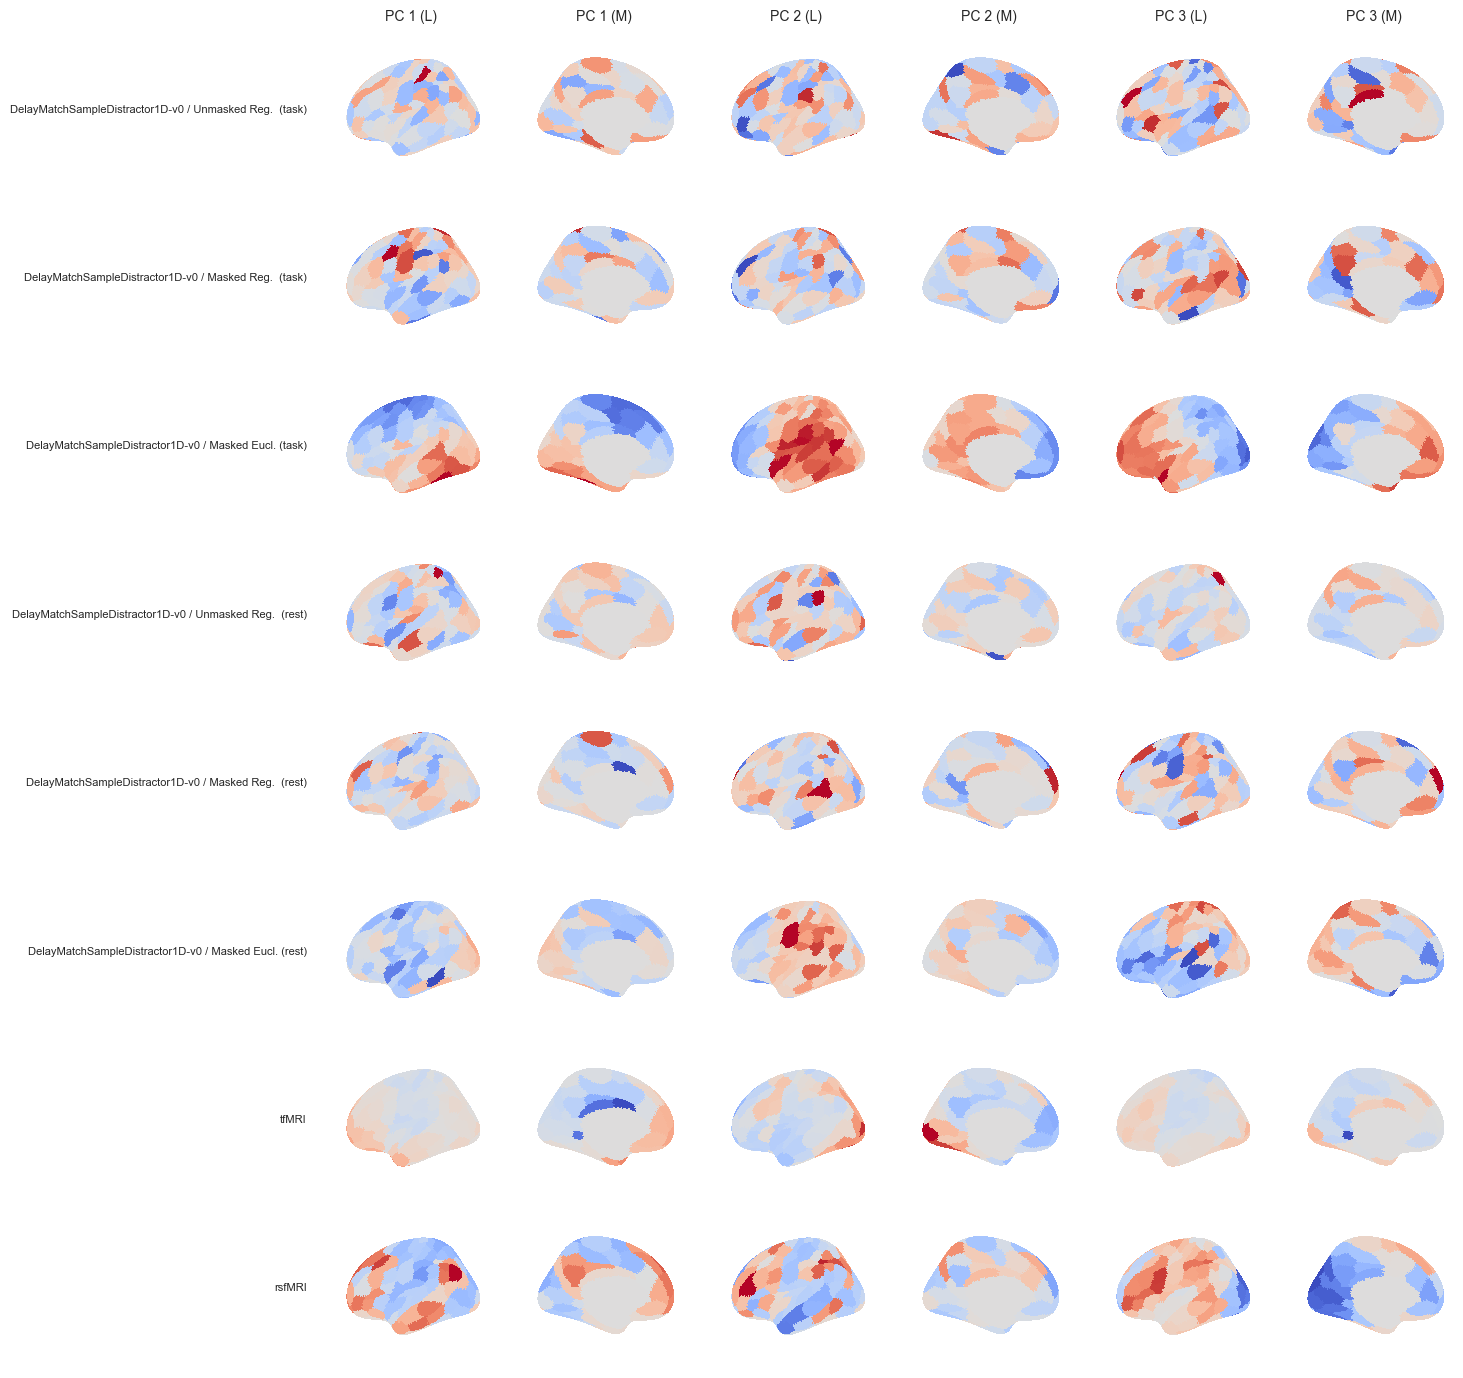

In [24]:
def align_and_average_components(pca_list, n_components=3):
    """Average PCA components across runs/subjects, with permutation matching and sign alignment.
    
    For each run, finds the best assignment of its PCs to the reference PCs 
    (from the first run) using the Hungarian algorithm on absolute cosine similarity.
    All runs are included in the average; diagnostics report match quality so 
    poor matches can be inspected without introducing selection bias.
    
    Returns the mean of aligned components and a dict of diagnostics.
    """
    
    ref = pca_list[0].components_[:n_components]
    aligned = []
    match_qualities = []  # per-run list of per-PC cosine similarities
    
    for ri, pca_obj in enumerate(pca_list):
        comps = pca_obj.components_[:n_components].copy()
        
        # absolute cosine similarity between this run's PCs and reference PCs
        cos_sim = np.abs(ref @ comps.T)  # (n_components, n_components)
        
        # optimal one-to-one assignment (maximize similarity)
        row_ind, col_ind = linear_sum_assignment(-cos_sim)
        
        # reorder and sign-align
        matched = np.zeros_like(comps)
        pc_corrs = np.zeros(n_components)
        for k in range(n_components):
            matched[k] = comps[col_ind[k]]
            pc_corrs[k] = cos_sim[k, col_ind[k]]
            if ref[k] @ matched[k] < 0:
                matched[k] *= -1
        
        match_qualities.append(pc_corrs)
        aligned.append(matched)
    
    match_qualities = np.array(match_qualities)  # (n_runs, n_components)
    mean_comps = np.mean(aligned, axis=0)  # shape (n_components, n_nodes)
    diagnostics = {
        'match_qualities': match_qualities,
        'mean_cosine_sim': match_qualities.mean(axis=0),
        'min_cosine_sim': match_qualities.min(axis=0),
        'n_poor_matches': np.sum(match_qualities < 0.5, axis=0),  # per PC
    }
    return mean_comps, diagnostics


# --- Select top-N runs by weight-kernel similarity ---
# For models with a spatial kernel, select the runs whose learned weights
# most closely match their target kernel (by cosine similarity).
# Models without a spatial kernel use all runs.
n_top_runs = 100

_ABS_REG = {'pearson_abs', 'pearson_abs_l2s'}
_KERNEL_TYPES_WITH_EMBEDDING = {'euclidean', 'sf_axis', 'sa_axis', 'ut_axis'}

top_run_indices = {}  # model_idx -> list of selected run indices
for model_idx in range(n_models):
    this = model_params.iloc[model_idx]
    kt = this.kernel_type
    n_runs = len(trained_models_all[model_idx])

    if kt not in _KERNEL_TYPES_WITH_EMBEDDING:
        top_run_indices[model_idx] = list(range(n_runs))
        continue

    # training kernel (1 - K, off-diagonal), matched to what the loss optimized
    K_train, _ = utils.load_embedding(kernel_type=kt, datadir=datadir, hidden_size=hidden_size,
                                      kernel_normalization=this.kernel_normalization)
    K_train = np.asarray(K_train)
    include_mask = ~np.eye(K_train.shape[0], dtype=np.bool_)
    target_vec = (1.0 - K_train)[include_mask]
    target_c = target_vec - target_vec.mean()
    use_abs = this.reg_type in _ABS_REG

    cos_sims = np.zeros(n_runs)
    for run_idx in range(n_runs):
        W_hh = trained_models_all[model_idx][run_idx]['rnn'].rnn.weight_hh_l0.detach().cpu().numpy()
        weight_vec = W_hh[include_mask]
        weight_metric = np.abs(weight_vec) if use_abs else weight_vec  # match loss objective
        wc = weight_metric - weight_metric.mean()
        cos_sims[run_idx] = np.dot(wc, target_c) / (np.linalg.norm(wc) * np.linalg.norm(target_c))

    n_select = min(n_top_runs, n_runs)
    selected = np.argsort(cos_sims)[-n_select:]
    top_run_indices[model_idx] = sorted(selected)
    print(f'{this.task_no_modifier} / {this.kernel_label}: '
          f'selected top {n_select}/{n_runs} runs '
          f'(W-K cosine range: {cos_sims[selected].min():.3f} – {cos_sims[selected].max():.3f})')

# --- Collect mean PC loadings for each source ---
n_pcs_to_plot = 3
sources = []  # list of (label, components_array)

# RNN models (task)
for model_idx in range(n_models):
    this = model_params.iloc[model_idx]
    label = f"{this.task_no_modifier} / {this.kernel_label} (task)"
    sel = top_run_indices[model_idx]
    pca_list = [pca_hidden_task[model_idx][r]['pca'] for r in sel]
    mean_comps, diag = align_and_average_components(pca_list, n_pcs_to_plot)
    n_poor = diag['n_poor_matches']
    if np.any(n_poor > 0):
        print(f'{label}: {n_poor}/{len(sel)} runs with poor PC match (cosine < 0.5); '
              f'mean sim = {diag["mean_cosine_sim"]}')
    sources.append((label, mean_comps))

# RNN models (rest)
for model_idx in range(n_models):
    this = model_params.iloc[model_idx]
    label = f"{this.task_no_modifier} / {this.kernel_label} (rest)"
    sel = top_run_indices[model_idx]
    pca_list = [pca_hidden_rest[model_idx][r]['pca'] for r in sel]
    mean_comps, diag = align_and_average_components(pca_list, n_pcs_to_plot)
    n_poor = diag['n_poor_matches']
    if np.any(n_poor > 0):
        print(f'{label}: {n_poor}/{len(sel)} runs with poor PC match (cosine < 0.5); '
              f'mean sim = {diag["mean_cosine_sim"]}')
    sources.append((label, mean_comps))

# Task fMRI
pca_list_fmri_task = [pca_fmri_task[si]['pca'] for si in range(n_fmri_subj)]
mean_comps_fmri_task, diag = align_and_average_components(pca_list_fmri_task, n_pcs_to_plot)
n_poor = diag['n_poor_matches']
if np.any(n_poor > 0):
    print(f'tfMRI: {n_poor} subjects with poor match (cosine < 0.5) per PC; '
          f'mean sim = {diag["mean_cosine_sim"]}')
sources.append(('tfMRI', mean_comps_fmri_task))

# Rest fMRI
pca_list_fmri_rest = [pca_fmri_rest[si]['pca'] for si in range(n_fmri_subj)]
mean_comps_fmri_rest, diag = align_and_average_components(pca_list_fmri_rest, n_pcs_to_plot)
n_poor = diag['n_poor_matches']
if np.any(n_poor > 0):
    print(f'rsfMRI: {n_poor} subjects with poor match (cosine < 0.5) per PC; '
          f'mean sim = {diag["mean_cosine_sim"]}')
sources.append(('rsfMRI', mean_comps_fmri_rest))

# --- Build the figure ---
n_rows = len(sources)
views = ['lateral', 'medial']
n_views = len(views)
n_cols = n_pcs_to_plot * n_views

lh_annot, _ = _get_schaefer_annot(n_parcels=200, yeo_networks=7)
fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 1.8 * n_rows),
                         subplot_kw={'projection': '3d'})
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, (label, comps) in enumerate(sources):
    for pc in range(n_pcs_to_plot):
        vtx_data = _roi_to_vtx(comps[pc], lh_annot)
        vmax = np.max(np.abs(comps[pc]))
        for vi, view in enumerate(views):
            col = pc * n_views + vi
            ax = axes[row, col]
            nilearn_plotting.plot_surf_roi(
                fsaverage['infl_left'], roi_map=vtx_data,
                hemi='left', view=view,
                vmin=-vmax, vmax=vmax,
                bg_map=fsaverage['sulc_left'], bg_on_data=False,
                axes=ax, darkness=0.5,
                cmap='coolwarm', colorbar=False,
            )
            if row == 0:
                ax.set_title(f'PC {pc+1} ({view[0].upper()})', fontsize=10)
    # row label
    axes[row, 0].text2D(-0.15, 0.5, label, transform=axes[row, 0].transAxes,
                        fontsize=8, va='center', ha='right', rotation=0)

fig.subplots_adjust(left=0.18, right=0.95, bottom=0.02, top=0.95,
                    wspace=0.0, hspace=0.05)
plt.show()

## PCA on hidden weights

Run PCA on the hidden-to-hidden weight matrix $W_{hh}$ to identify dominant structural motifs.
Each row of $W_{hh}$ is the incoming connectivity profile for one node, so PCA across rows
yields spatial components plottable on the brain surface, just like activity PCs.

In [25]:
# --- PCA on hidden-to-hidden weights ---
pca_weights = []  # list of dicts per model

for model_idx in range(n_models):
    this = model_params.iloc[model_idx]
    sel = top_run_indices[model_idx]
    print(f"{this.task_no_modifier} / {this.kernel_label}: "
          f"{len(sel)} runs selected")

    pca_runs = []
    ve_runs = np.zeros(len(sel))

    for ri, run_idx in enumerate(sel):
        W_hh = (trained_models_all[model_idx][run_idx]['rnn']
                .rnn.weight_hh_l0.detach().cpu().numpy())  # [N, N]

        pca, _, _, _, n_nodes, var_exp = fit_pca(W_hh, n_components=n_pc)
        pca_runs.append(pca)
        ve_runs[ri] = var_exp['total']

    mean_comps, diag = align_and_average_components(pca_runs, n_pcs_to_plot)
    n_poor = diag['n_poor_matches']
    if np.any(n_poor > 0):
        print(f'  {n_poor} runs with poor PC match (cosine < 0.5); '
              f'mean sim = {diag["mean_cosine_sim"]}')
    print(f'  Mean variance explained (top {n_pcs_to_plot} PCs): '
          f'{ve_runs.mean()*100:.1f}%')

    pca_weights.append({
        'pca_runs': pca_runs,
        'mean_components': mean_comps,
        'var_exp_runs': ve_runs,
        'diagnostics': diag,
    })

print('Done.')

DelayMatchSampleDistractor1D-v0 / Unmasked Reg. : 100 runs selected
  [99 99 99] runs with poor PC match (cosine < 0.5); mean sim = [0.13306798 0.11693521 0.13787279]
  Mean variance explained (top 3 PCs): 66.0%
DelayMatchSampleDistractor1D-v0 / Masked Reg. : 100 runs selected
  [99 99 99] runs with poor PC match (cosine < 0.5); mean sim = [0.20828548 0.16524717 0.11067112]
  Mean variance explained (top 3 PCs): 68.1%
DelayMatchSampleDistractor1D-v0 / Masked Eucl.: 100 runs selected
  [98 99 97] runs with poor PC match (cosine < 0.5); mean sim = [0.22193463 0.14991427 0.2689715 ]
  Mean variance explained (top 3 PCs): 66.1%
Done.


/var/folders/t8/9fwt8w0s10v1ys1sgwwjm5dm0000gn/T/ipykernel_4634/3485037692.py:26: DeprecationWarning: Negative values in roi_map will no longer be allowed in Nilearn version 0.13
  nilearn_plotting.plot_surf_roi(
/var/folders/t8/9fwt8w0s10v1ys1sgwwjm5dm0000gn/T/ipykernel_4634/3485037692.py:26: DeprecationWarning: Non-integer values in roi_map will no longer be allowed in Nilearn version 0.13
  nilearn_plotting.plot_surf_roi(
/var/folders/t8/9fwt8w0s10v1ys1sgwwjm5dm0000gn/T/ipykernel_4634/3485037692.py:26: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nilearn_plotting.plot_surf_roi(


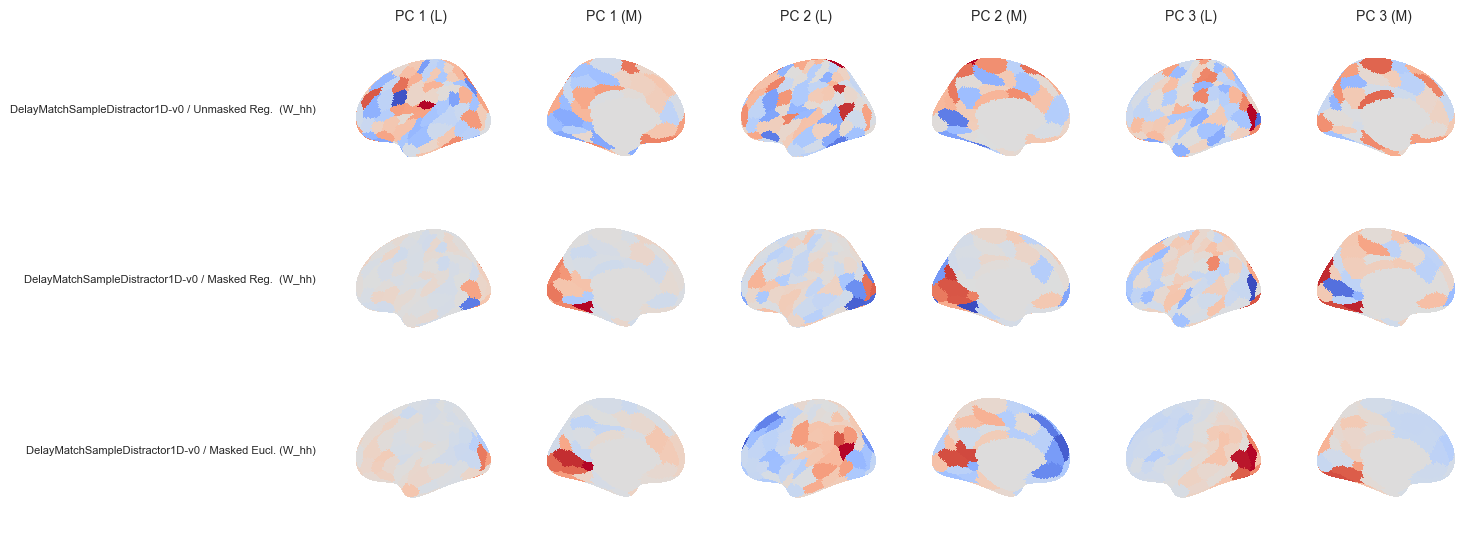

In [26]:
# --- Plot weight PCA components on brain surface ---
weight_sources = []
for model_idx in range(n_models):
    this = model_params.iloc[model_idx]
    label = f"{this.task_no_modifier} / {this.kernel_label} (W_hh)"
    weight_sources.append((label, pca_weights[model_idx]['mean_components']))

n_rows_w = len(weight_sources)
views = ['lateral', 'medial']
n_views = len(views)
n_cols_w = n_pcs_to_plot * n_views

fig, axes = plt.subplots(n_rows_w, n_cols_w,
                         figsize=(2.5 * n_cols_w, 1.8 * n_rows_w),
                         subplot_kw={'projection': '3d'})
if n_rows_w == 1:
    axes = axes[np.newaxis, :]

for row, (label, comps) in enumerate(weight_sources):
    for pc in range(n_pcs_to_plot):
        vtx_data = _roi_to_vtx(comps[pc], lh_annot)
        vmax = np.max(np.abs(comps[pc]))
        for vi, view in enumerate(views):
            col = pc * n_views + vi
            ax = axes[row, col]
            nilearn_plotting.plot_surf_roi(
                fsaverage['infl_left'], roi_map=vtx_data,
                hemi='left', view=view,
                vmin=-vmax, vmax=vmax,
                bg_map=fsaverage['sulc_left'], bg_on_data=False,
                axes=ax, darkness=0.5,
                cmap='coolwarm', colorbar=False,
            )
            if row == 0:
                ax.set_title(f'PC {pc+1} ({view[0].upper()})', fontsize=10)
    axes[row, 0].text2D(-0.15, 0.5, label, transform=axes[row, 0].transAxes,
                        fontsize=8, va='center', ha='right', rotation=0)

fig.subplots_adjust(left=0.18, right=0.95, bottom=0.02, top=0.95,
                    wspace=0.0, hspace=0.05)
plt.show()

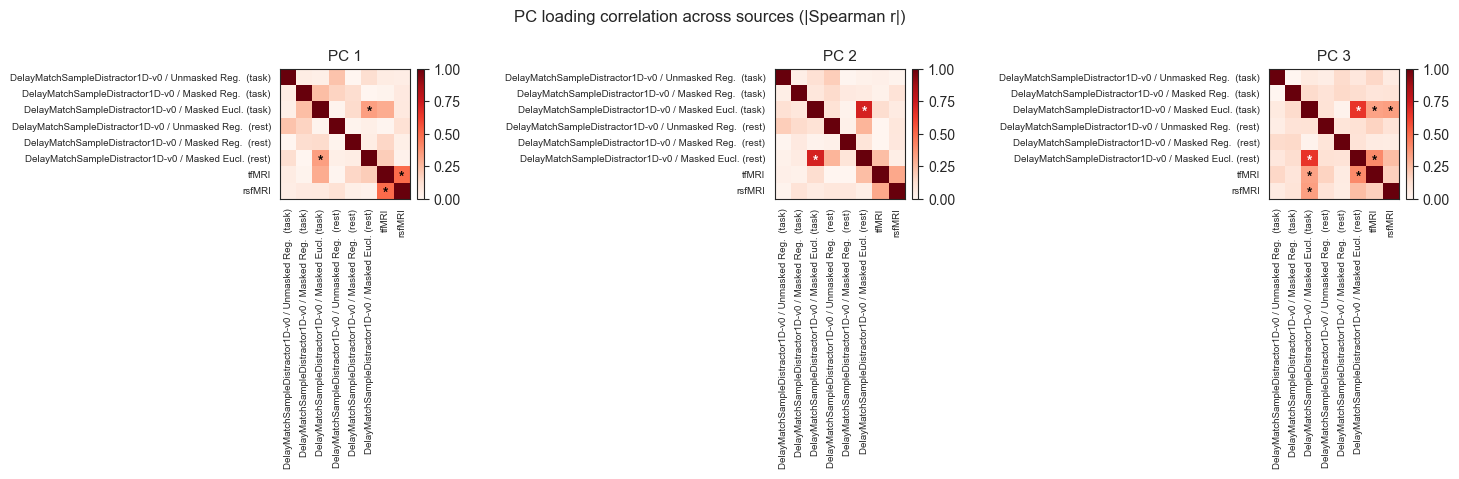

In [27]:
# Correlation heatmap: compare PC loadings (node weights) across all sources
# For each PC, compute the Spearman correlation between every pair of sources'
# mean component vectors, then display as a heatmap.
#
# We plot |r| (sequential colormap) rather than signed r: PCA eigenvectors are
# only defined up to sign, so anti-correlation between two independently fit
# PCs reflects an arbitrary sign flip, not a meaningful opposite relationship.
# Significance is unchanged since p-values are symmetric in the sign of r.

source_labels = [label for label, _ in sources]
n_sources = len(sources)

fig, axes = plt.subplots(1, n_pcs_to_plot, figsize=(5 * n_pcs_to_plot, 4.5),
                         squeeze=False)

n_nodes_corr = sources[0][1].shape[1]
n_pairs = n_sources * (n_sources - 1) // 2  # for Bonferroni correction

for pc in range(n_pcs_to_plot):
    corr_mat = np.zeros((n_sources, n_sources))
    pval_mat = np.ones((n_sources, n_sources))
    for i in range(n_sources):
        for j in range(n_sources):
            if i == j:
                corr_mat[i, j] = 1.0
                pval_mat[i, j] = 0.0
            else:
                r, p = stats.spearmanr(sources[i][1][pc], sources[j][1][pc])
                corr_mat[i, j] = r
                pval_mat[i, j] = p

    abs_corr_mat = np.abs(corr_mat)

    ax = axes[0, pc]
    im = ax.imshow(abs_corr_mat, cmap='Reds', vmin=0, vmax=1, aspect='equal')
    ax.set_xticks(range(n_sources))
    ax.set_xticklabels(source_labels, rotation=90, fontsize=7)
    ax.set_yticks(range(n_sources))
    ax.set_yticklabels(source_labels, fontsize=7)
    ax.set_title(f'PC {pc+1}', fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # mark significant cells (Bonferroni-corrected across unique pairs)
    for i in range(n_sources):
        for j in range(n_sources):
            if i == j:
                continue
            if pval_mat[i, j] < 0.05 / n_pairs:
                ax.text(j, i+0.2, '*', ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white' if abs_corr_mat[i, j] > 0.6 else 'black')

fig.suptitle('PC loading correlation across sources (|Spearman r|)',
             fontsize=12, y=1.02)
fig.tight_layout()

if save_figs:
    fig.savefig(os.path.join(outdir, 'pc_loading_correlation_heatmap.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()


### S-A axis on the cortical surface

The same surface display used for the PC loadings, applied to the
sensorimotor–association (S-A) axis map, with a Sydnor-style gold→purple
colormap (gold = sensorimotor / low rank, purple = association / high rank).
Shown for the left hemisphere to match the PC plots.

/var/folders/t8/9fwt8w0s10v1ys1sgwwjm5dm0000gn/T/ipykernel_4634/3967114085.py:20: DeprecationWarning: Non-integer values in roi_map will no longer be allowed in Nilearn version 0.13
  nilearn_plotting.plot_surf_roi(
/var/folders/t8/9fwt8w0s10v1ys1sgwwjm5dm0000gn/T/ipykernel_4634/3967114085.py:20: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nilearn_plotting.plot_surf_roi(


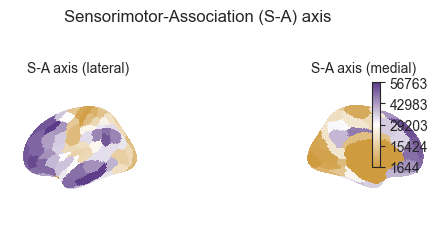

In [28]:
# Display the S-A axis on the cortical surface, matching the PC-loading surface
# plots above but with a Sydnor-style gold->purple colormap.

# gold (sensorimotor / low rank) -> white -> purple (association / high rank),
# approximating the Sydnor et al. S-A axis colormap.
sa_cmap = LinearSegmentedColormap.from_list(
    'sa_axis', ['#cf9b3f', '#ffffff', '#5b3a87'])

# S-A values for the hidden nodes (left hemisphere, first hidden_size ROIs).
sa_vals = np.ravel(sa_axis)[:hidden_size]

lh_annot_sa, _ = _get_schaefer_annot(n_parcels=200, yeo_networks=7)
fsaverage_sa = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
vtx_data = _roi_to_vtx(sa_vals, lh_annot_sa)

views = ['lateral', 'medial']
fig, axes = plt.subplots(1, len(views), figsize=(2.5 * len(views), 2.2),
                         subplot_kw={'projection': '3d'})
for vi, view in enumerate(views):
    nilearn_plotting.plot_surf_roi(
        fsaverage_sa['infl_left'], roi_map=vtx_data,
        hemi='left', view=view,
        vmin=np.nanmin(sa_vals), vmax=np.nanmax(sa_vals),
        bg_map=fsaverage_sa['sulc_left'], bg_on_data=False,
        axes=axes[vi], darkness=0.5,
        cmap=sa_cmap, colorbar=(vi == len(views) - 1),
    )
    axes[vi].set_title(f'S-A axis ({view})', fontsize=10)

fig.suptitle('Sensorimotor-Association (S-A) axis', fontsize=12, y=1.02)
fig.tight_layout()
if save_figs:
    fig.savefig(os.path.join(outdir, 'sa_axis_surface.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

## SA-axis variance explained by PC subspace (joint regression)

Single-number version of the SA analysis. Instead of correlating each PC with
the SA axis separately, regress the SA axis on a source's PC loadings **together**
(multiple regression). The R² is one "how much SA" number per source — the
fraction of SA-axis variance the source's PC subspace can reconstruct. One bar
per source; significance is the regression F-test, Bonferroni-corrected across
sources. The dashed line marks the chance level E[R²] ≈ k/(n−1).

SA-axis regression (k=5 PCs, n=100 nodes), F-test Bonferroni alpha=6.3e-03, R2 threshold=0.156:
  DelayMatchSampleDistractor1D-v0 / Unmasked Reg.  (task) R2=0.018  adjR2=-0.034  p=8.8e-01 
  DelayMatchSampleDistractor1D-v0 / Masked Reg.  (task) R2=0.044  adjR2=-0.007  p=5.1e-01 
  DelayMatchSampleDistractor1D-v0 / Masked Eucl. (task) R2=0.430  adjR2=0.399  p=2.6e-10 *
  DelayMatchSampleDistractor1D-v0 / Unmasked Reg.  (rest) R2=0.033  adjR2=-0.019  p=6.7e-01 
  DelayMatchSampleDistractor1D-v0 / Masked Reg.  (rest) R2=0.010  adjR2=-0.043  p=9.7e-01 
  DelayMatchSampleDistractor1D-v0 / Masked Eucl. (rest) R2=0.357  adjR2=0.323  p=5.5e-08 *
  tfMRI                                            R2=0.453  adjR2=0.424  p=3.9e-11 *
  rsfMRI                                           R2=0.662  adjR2=0.644  p=9.4e-21 *


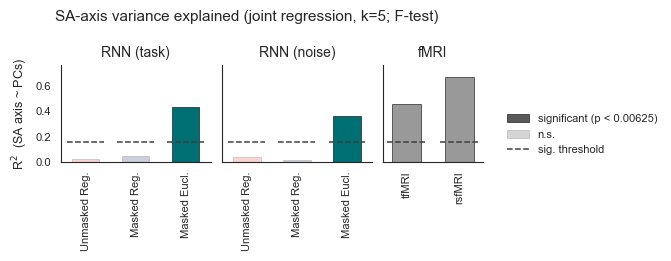

In [29]:
# Joint PC -> SA-axis regression: one R^2 per source.
#
# X = a source's first k PC loadings (k x n_nodes), y = the SA axis. R^2 is the
# fraction of SA-axis variance reconstructable from the source's PC subspace.
# This cell defines the shared regression + bar-plot helpers; the next cell
# reuses _plot_sa_bars with a spatial spin null to render an identical figure.
# The dashed tick on each bar is the SIGNIFICANCE THRESHOLD (the null critical
# value at alpha), not the null mean -- so a bar clears its tick iff it is
# significant, matching the opacity.

k = n_pc # n_pcs_to_plot
n_nodes_pc = sources[0][1].shape[1]
sa_vec = np.ravel(sa_axis)[:n_nodes_pc]


def _sa_r2(comps, target):
    """R^2 of regressing `target` (n_nodes,) on a source's first k PC loadings."""
    X = np.asarray(comps[:k]).T
    X = X - X.mean(axis=0, keepdims=True)
    y = target - target.mean()
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return 1.0 - float(((y - X @ beta) ** 2).sum()) / float((y ** 2).sum())


def _sa_ftest(r2, n, k):
    """Regression F-test p-value: R^2 with k predictors, n observations."""
    F = (r2 / k) / ((1.0 - r2) / (n - k - 1))
    return float(stats.f.sf(F, k, n - k - 1))


def _ftest_r2_crit(alpha, n, k):
    """Critical R^2 at which the regression F-test reaches `alpha`."""
    Fc = stats.f.ppf(1 - alpha, k, n - k - 1)
    return (Fc * k) / (Fc * k + (n - k - 1))


def _plot_sa_bars(r2_by, sig_by, thresh_by, alpha, title, savename):
    """One R^2 bar per source in RNN(task)/RNN(noise)/fMRI panels. Opacity
    encodes significance; a per-bar dashed tick marks the significance threshold
    (`thresh_by`). Legend sits to the right of the panels."""
    source_labels = [lab for lab, _ in sources]
    n_src = len(sources)
    palette = utils.get_my_colors(cat_trio=(len(kernel_labels) <= 3), as_list=True)
    korder = list(model_params.kernel_label.unique())
    k2c = {kk: palette[i] for i, kk in enumerate(korder)}
    fmri_color = (0.6, 0.6, 0.6)
    rnn_colors = [k2c[model_params.kernel_label.iloc[m]] for m in range(n_models)]
    source_colors = rnn_colors + rnn_colors + [fmri_color] * (n_src - 2 * n_models)

    short = [None] * n_src
    for m in range(n_models):
        kl = model_params.kernel_label.iloc[m].strip()
        short[m] = kl; short[n_models + m] = kl
    for si in range(2 * n_models, n_src):
        short[si] = source_labels[si]
    segments = [('RNN (task)', list(range(0, n_models))),
                ('RNN (noise)', list(range(n_models, 2 * n_models))),
                ('fMRI', list(range(2 * n_models, n_src)))]

    set_font_size(9)
    seg_sizes = [max(1, len(idxs)) for _, idxs in segments]
    fig, axes = plt.subplots(1, len(segments), figsize=(max(5, 0.55 * n_src), 2.6),
                             sharey=True, gridspec_kw={'width_ratios': seg_sizes})
    ymax = max(0.1, 1.15 * max(max(r2_by.values()), max(thresh_by.values())))
    bw = 0.55
    for ax, (seg_title, idxs) in zip(axes, segments):
        ax.set_title(seg_title, fontsize=10)
        if not idxs:
            ax.axis('off'); continue
        xloc = np.arange(len(idxs))
        for j, si in enumerate(idxs):
            lab = source_labels[si]
            ax.bar(xloc[j], r2_by[lab], width=bw, color=source_colors[si],
                   alpha=1.0 if sig_by[lab] else 0.25,
                   edgecolor='k', linewidth=0.4, zorder=2)
            ax.hlines(thresh_by[lab], xloc[j] - bw / 1.5, xloc[j] + bw / 1.5,
                      color='0.25', lw=1.1, ls='--', zorder=3)
        ax.set_xticks(xloc)
        ax.set_xticklabels([short[si] for si in idxs])
        plt.setp(ax.get_xticklabels(), rotation=90, ha='center', va='top', fontsize=8)
        ax.margins(x=0.05)
        sns.despine(ax=ax, right=True, top=True)
    axes[0].set_ylabel(r'R$^2$  (SA axis ~ PCs)')
    axes[0].set_ylim(0, ymax)
    handles = [Patch(facecolor='0.35', edgecolor='k', linewidth=0.4, alpha=1.0,
                     label=f'significant (p < {alpha:g})'),
               Patch(facecolor='0.35', edgecolor='k', linewidth=0.4, alpha=0.25,
                     label='n.s.'),
               Line2D([0], [0], color='0.25', lw=1.1, ls='--', label='sig. threshold')]
    fig.suptitle(title, fontsize=11)
    fig.tight_layout(); fig.subplots_adjust(wspace=0.08)
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               frameon=False, fontsize=8)
    if save_figs:
        fig.savefig(os.path.join(outdir, savename), dpi=300,
                    bbox_inches='tight', pad_inches=0.01)
    plt.show()


# --- parametric F-test version (Bonferroni across sources) ---
sa_reg_df = pd.DataFrame([{'source': lab, 'r2': _sa_r2(comps, sa_vec)}
                          for lab, comps in sources])
sa_reg_df['adj_r2'] = 1 - (1 - sa_reg_df['r2']) * (n_nodes_pc - 1) / (n_nodes_pc - k - 1)
sa_reg_df['p'] = sa_reg_df['r2'].apply(lambda r: _sa_ftest(r, n_nodes_pc, k))
alpha_bonf_reg = 0.05 / len(sa_reg_df)
sa_reg_df['sig'] = sa_reg_df['p'] < alpha_bonf_reg
r2_crit = _ftest_r2_crit(alpha_bonf_reg, n_nodes_pc, k)   # threshold line

print(f'SA-axis regression (k={k} PCs, n={n_nodes_pc} nodes), '
      f'F-test Bonferroni alpha={alpha_bonf_reg:.1e}, R2 threshold={r2_crit:.3f}:')
for _, r in sa_reg_df.iterrows():
    print(f"  {r['source']:48s} R2={r['r2']:.3f}  adjR2={r['adj_r2']:.3f}  "
          f"p={r['p']:.1e} {'*' if r['sig'] else ''}")

_plot_sa_bars(dict(zip(sa_reg_df['source'], sa_reg_df['r2'])),
              dict(zip(sa_reg_df['source'], sa_reg_df['sig'])),
              {lab: r2_crit for lab in sa_reg_df['source']},
              alpha_bonf_reg,
              f'SA-axis variance explained (joint regression, k={k}; F-test)',
              'sa_axis_joint_regression_bar_ftest.svg')


## SA-axis regression — spin-null significance

Identical to the bar plot above, but significance comes from a **spatial spin
null** on the S-A axis (rotate the SA map on the sphere via `spin_permutations`,
recompute R² for each spin, rank the observed). This controls for the spatial
autocorrelation of the S-A axis, which the parametric F-test ignores. The
printed table reports the null median / 95th-percentile R² per source — the true
spin threshold, which sits well above the iid chance line drawn on the figure.

SA-axis regression spin null (5000 spins), alpha=0.05 (no Bonferroni):
  DelayMatchSampleDistractor1D-v0 / Unmasked Reg.  (task) R2=0.018  null_mean=0.023  thresh(p95)=0.057  p_spin=5.2e-01 
  DelayMatchSampleDistractor1D-v0 / Masked Reg.  (task) R2=0.044  null_mean=0.033  thresh(p95)=0.081  p_spin=2.7e-01 
  DelayMatchSampleDistractor1D-v0 / Masked Eucl. (task) R2=0.430  null_mean=0.244  thresh(p95)=0.391  p_spin=1.6e-02 *
  DelayMatchSampleDistractor1D-v0 / Unmasked Reg.  (rest) R2=0.033  null_mean=0.030  thresh(p95)=0.075  p_spin=3.7e-01 
  DelayMatchSampleDistractor1D-v0 / Masked Reg.  (rest) R2=0.010  null_mean=0.026  thresh(p95)=0.068  p_spin=7.6e-01 
  DelayMatchSampleDistractor1D-v0 / Masked Eucl. (rest) R2=0.357  null_mean=0.141  thresh(p95)=0.272  p_spin=3.0e-03 *
  tfMRI                                            R2=0.453  null_mean=0.108  thresh(p95)=0.256  p_spin=8.0e-04 *
  rsfMRI                                           R2=0.662  null_mean=0.122  thresh(p95)=0.303  p_sp

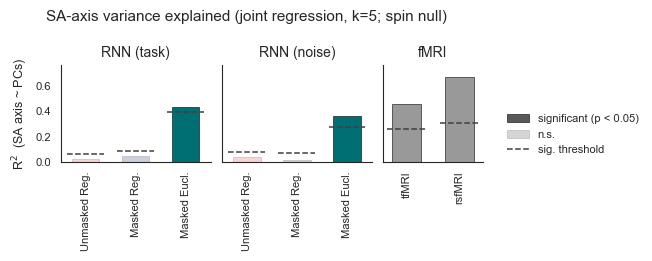

In [30]:
# Spin-null significance for the SA-axis regression. Same bars as above; only
# the highlighted sources and the per-bar threshold ticks differ. Rotating the
# SA map on the sphere preserves its autocorrelation, so each source's threshold
# (null 95th percentile = critical value for p_spin<0.05) sits well above the
# iid level. No Bonferroni: the spin null already controls for autocorrelation.

n_spins = 5000
# Spin from the FreeSurfer-sphere coords -- the SAME source the trained nulls
# (fixed-init, mixed-effects) use in train_rnn.py, NOT the MNI centroids. On the
# sphere the parcels tile a near-full ball, so reassignment residuals are small
# (~13 deg vs ~58 for MNI centroids) and the SA map's autocorrelation is better
# preserved (~92% vs 85%). seed=0 matches the training null_seed.
sphere_coords = np.loadtxt(os.path.join(datadir, f'schaefer{hidden_size * 2}_LH_sphere_coords.txt'))
assert sphere_coords.shape == (n_nodes_pc, 3), f'sphere coords shape {sphere_coords.shape}'
spin_perms = spin_permutations(sphere_coords, n_spins, seed=0)  # (n_spins, n_nodes_pc)
sa_spun = sa_vec[spin_perms]                                   # (n_spins, n_nodes_pc)

alpha_spin = 0.05                                              # raw, no Bonferroni
spin_rows = []
for lab, comps in sources:
    obs = _sa_r2(comps, sa_vec)
    null = np.array([_sa_r2(comps, sa_spun[s]) for s in range(n_spins)])
    p_spin = (1 + int((null >= obs).sum())) / (n_spins + 1)    # one-sided, +1 corr.
    spin_rows.append({'source': lab, 'r2': obs, 'p_spin': p_spin,
                      'null_mean': float(null.mean()),
                      'thresh': float(np.quantile(null, 1 - alpha_spin))})  # critical value
spin_df = pd.DataFrame(spin_rows)
spin_df['sig'] = spin_df['p_spin'] < alpha_spin

print(f'SA-axis regression spin null ({n_spins} spins), alpha={alpha_spin} (no Bonferroni):')
for _, r in spin_df.iterrows():
    print(f"  {r['source']:48s} R2={r['r2']:.3f}  null_mean={r['null_mean']:.3f}  "
          f"thresh(p95)={r['thresh']:.3f}  p_spin={r['p_spin']:.1e} {'*' if r['sig'] else ''}")

_plot_sa_bars(dict(zip(spin_df['source'], spin_df['r2'])),
              dict(zip(spin_df['source'], spin_df['sig'])),
              dict(zip(spin_df['source'], spin_df['thresh'])),
              alpha_spin,
              f'SA-axis variance explained (joint regression, k={k}; spin null)',
              'sa_axis_joint_regression_bar_spin.svg')


## Project fMRI into RNN PC space


In [31]:
def project_fmri_one_model(model_idx):
    """Project each subject's fMRI onto both the task-RNN and rest-RNN PC bases.

    Returns arrays of per-component variance explained for all four combinations:
      - matched:  task-RNN -> task-fMRI, rest-RNN -> rest-fMRI
      - cross:    rest-RNN -> task-fMRI, task-RNN -> rest-fMRI
    Plus the projected fMRI time series in the matched bases (used downstream).
    """
    n_runs = len(pca_hidden_task[model_idx])
    # variance-explained arrays: (n_pc, n_subj, n_runs)
    ve_tt = np.zeros((n_pc, n_fmri_subj, n_runs))  # task-RNN -> task-fMRI (matched)
    ve_rr = np.zeros((n_pc, n_fmri_subj, n_runs))  # rest-RNN -> rest-fMRI (matched)
    ve_rt = np.zeros((n_pc, n_fmri_subj, n_runs))  # rest-RNN -> task-fMRI (cross)
    ve_tr = np.zeros((n_pc, n_fmri_subj, n_runs))  # task-RNN -> rest-fMRI (cross)

    fmri_task_projected_model = []
    fmri_rest_projected_model = []

    for run_idx in tqdmnb(range(n_runs), desc=f'Model {model_idx+1}/{n_models}',
                          position=model_idx, leave=True):
        this_pca_task = pca_hidden_task[model_idx][run_idx]['pca']
        this_pca_rest = pca_hidden_rest[model_idx][run_idx]['pca']

        fmri_task_projected_run = []
        fmri_rest_projected_run = []
        for subj_idx in range(n_fmri_subj):
            this_fmri_task = fmri_task_ts[:, :, subj_idx]
            this_fmri_rest = fmri_rest_ts[:, :, subj_idx]

            # task fMRI: matched (task-RNN) + cross (rest-RNN)
            proj_tt, var_tt = pca_projection(this_fmri_task, this_pca_task, centering_mean='data')
            _,        var_rt = pca_projection(this_fmri_task, this_pca_rest, centering_mean='data')
            ve_tt[:, subj_idx, run_idx] = var_tt['each']
            ve_rt[:, subj_idx, run_idx] = var_rt['each']
            fmri_task_projected_run.append({
                'fmri_pc': proj_tt,
                'variance_explained': var_tt,
                'subject': fmri_task_subjnames[subj_idx],
            })

            # rest fMRI: matched (rest-RNN) + cross (task-RNN)
            proj_rr, var_rr = pca_projection(this_fmri_rest, this_pca_rest, centering_mean='data')
            _,        var_tr = pca_projection(this_fmri_rest, this_pca_task, centering_mean='data')
            ve_rr[:, subj_idx, run_idx] = var_rr['each']
            ve_tr[:, subj_idx, run_idx] = var_tr['each']
            fmri_rest_projected_run.append({
                'fmri_pc': proj_rr,
                'variance_explained': var_rr,
            })

        fmri_task_projected_model.append(fmri_task_projected_run)
        fmri_rest_projected_model.append(fmri_rest_projected_run)

    return (fmri_task_projected_model, fmri_rest_projected_model,
            ve_tt, ve_rr, ve_rt, ve_tr)


results = Parallel(n_jobs=-1, prefer='threads')(
    delayed(project_fmri_one_model)(i) for i in range(n_models)
)

fmri_task_projected = [r[0] for r in results]
fmri_rest_projected = [r[1] for r in results]
# Matched pairings: RNN regime matches fMRI modality.
fmri_task_variance_explained = [r[2] for r in results]  # task-RNN -> task-fMRI
fmri_rest_variance_explained = [r[3] for r in results]  # rest-RNN -> rest-fMRI
# Cross-modal pairings: RNN regime opposite to fMRI modality.
fmri_task_ve_cross = [r[4] for r in results]            # rest-RNN -> task-fMRI
fmri_rest_ve_cross = [r[5] for r in results]            # task-RNN -> rest-fMRI


Model 1/3:   0%|          | 0/100 [00:00<?, ?it/s]

Model 3/3:   0%|          | 0/100 [00:00<?, ?it/s]

Model 2/3:   0%|          | 0/100 [00:00<?, ?it/s]

## Plot fMRI variance explained


100 (100%) -- DelayMatchSampleDistractor1D-v0 -- Unmasked Reg. 
100 (100%) -- DelayMatchSampleDistractor1D-v0 -- Masked Reg. 
 99 ( 99%) -- DelayMatchSampleDistractor1D-v0 -- Masked Eucl.


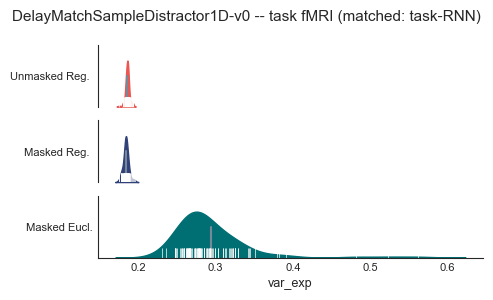

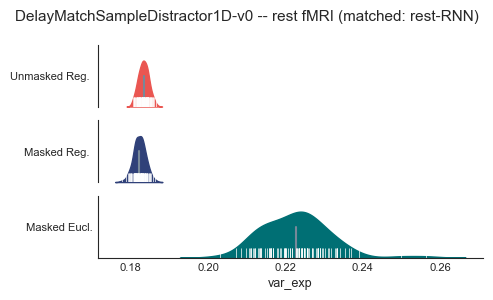

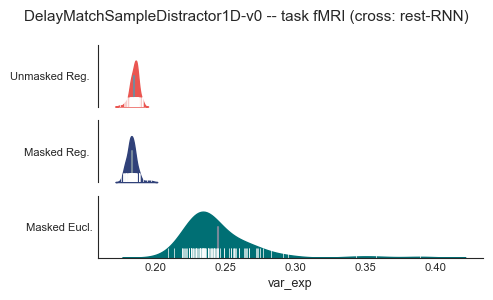

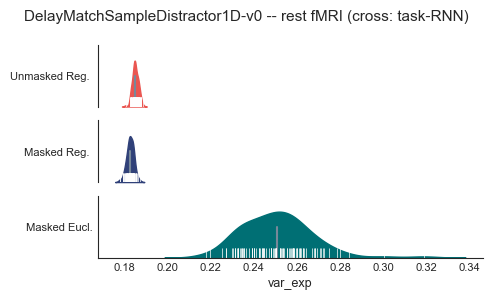

In [32]:
n_kernels_ve = len(kernel_labels)
if n_kernels_ve <= 3:
    color_palette_ve = utils.get_my_colors(cat_trio=True, as_list=True)
else:
    color_palette_ve = utils.get_my_colors(cat_trio=False, as_list=True)
# ensure we have enough colors
color_palette_ve = color_palette_ve[:n_kernels_ve]

# Four VE arrays per fMRI modality x RNN basis combination, all normalized by
# the unified inter-subject baseline:
#   matched_task_fmri = task-RNN -> task-fMRI
#   matched_rest_fmri = rest-RNN -> rest-fMRI
#   cross_task_fmri   = rest-RNN -> task-fMRI
#   cross_rest_fmri   = task-RNN -> rest-fMRI
ve_specs = [
    ('matched_task_fmri', fmri_task_variance_explained, 'task fMRI (matched: task-RNN)'),
    ('matched_rest_fmri', fmri_rest_variance_explained, 'rest fMRI (matched: rest-RNN)'),
    ('cross_task_fmri',   fmri_task_ve_cross,           'task fMRI (cross: rest-RNN)'),
    ('cross_rest_fmri',   fmri_rest_ve_cross,           'rest fMRI (cross: task-RNN)'),
]

records_by_key = {key: [] for key, _, _ in ve_specs}

for task_idx in range(n_tasks):
    for model_idx in range(n_models):
        if model_params.task_no_modifier.iloc[model_idx] not in task_names[task_idx]:
            continue
        this_kernel = model_params.kernel_label.iloc[model_idx]
        learned_runs = test_accuracy_pca[model_idx] > 0.
        learned_runs_frac = sum(learned_runs) / len(test_accuracy_pca[model_idx])
        print(f'{sum(learned_runs):3d} ({int(learned_runs_frac*100):3d}%) -- {task_names[task_idx]} -- {this_kernel}')
        for key, ve_arr, _ in ve_specs:
            if learned_runs_frac > 0.1:
                vals = (ve_arr[model_idx][:, :, learned_runs]
                        .mean(axis=2).sum(axis=0) / fmri_intersubj_var_exp)
            else:
                vals = np.full((n_fmri_subj,), np.nan)
            for v in vals:
                records_by_key[key].append({'kernel': this_kernel,
                                            'task': task_names[task_idx],
                                            'var_exp': v})

df_ve_by_key = {key: pd.DataFrame(records_by_key[key]) for key in records_by_key}

kernel_order = list(model_params.kernel_label.unique())

for task_idx in range(n_tasks):
    for key, _, label in ve_specs:
        df_t = df_ve_by_key[key]
        df_p = df_t[df_t['task'] == task_names[task_idx]]
        fig = categorical_kde_plot(df_p, variable='var_exp', category='kernel',
                                   category_order=kernel_order, horizontal=1,
                                   color_palette=color_palette_ve,
                                   title=f'{task_names[task_idx]} -- {label}')
        if save_figs:
            fig.savefig(os.path.join(outdir, f'fmri_ve_{key}_{task_names[task_idx]}.svg'),
                        dpi=300, bbox_inches='tight', pad_inches=0.01)


## Variance decomposition: task-RNN, rest-RNN, and their union as predictors of fMRI

For each (model, run, subject) and each fMRI modality (task / rest), compute three
subspace variance-explained values relative to the RNN PC bases:

- $R^2_T$: fMRI projected onto the **task**-RNN PC subspace (5-dim).
- $R^2_R$: fMRI projected onto the **rest**-RNN PC subspace (5-dim).
- $R^2_{T \cup R}$: fMRI projected onto an SVD-orthonormalized **union** of the
  two bases (up to 10-dim).

Venn-style commonality decomposition:

- unique-task $= R^2_{T \cup R} - R^2_R \geq 0$
- unique-rest $= R^2_{T \cup R} - R^2_T \geq 0$
- shared $= R^2_T + R^2_R - R^2_{T \cup R}$

The unique components are non-negative by construction (the union subspace
contains each individual subspace). The shared component is typically
non-negative (overlap of the two subspaces produces variance double-counted in
$R^2_T + R^2_R$) but can occasionally be slightly negative when the bases are
geometrically arranged like a "suppressor" pair — a known feature of
commonality analysis, not a numerical bug.

All values are normalized by the unified inter-subject baseline
(`fmri_intersubj_var_exp`).


In [33]:
def _orth_basis(M, rtol=1e-10):
    """SVD-based orthonormal basis for the column space of M, robust to
    rank deficiency. Returns an array of shape (M.shape[0], rank).
    """
    if M.shape[1] == 0:
        return np.zeros((M.shape[0], 0))
    U, S, _ = np.linalg.svd(M, full_matrices=False)
    if S.size == 0:
        return np.zeros((M.shape[0], 0))
    tol = rtol * S[0]
    rank = int((S > tol).sum())
    return U[:, :rank]


def _subspace_ve(data, basis):
    """Fraction of variance of `data` (T, N) lying in the span of an
    orthonormal `basis` (N, k). Data is centered per-feature first, matching
    the `centering_mean='data'` convention used by `pca_projection`.
    """
    X = data - data.mean(axis=0, keepdims=True)
    total = float((X ** 2).sum())
    if total <= 0.0 or basis.shape[1] == 0:
        return 0.0
    proj = X @ basis            # (T, k)
    return float((proj ** 2).sum() / total)


def decompose_one_model(model_idx):
    n_runs = len(pca_hidden_task[model_idx])
    # one dict per fMRI modality, holding (n_subj, n_runs) arrays per component
    components = ('ve_t', 've_r', 've_union', 'unique_t', 'unique_r', 'shared')
    out = {mod: {k: np.zeros((n_fmri_subj, n_runs)) for k in components}
           for mod in ('task', 'rest')}
    out['union_rank'] = np.zeros(n_runs, dtype=int)

    for run_idx in tqdmnb(range(n_runs),
                          desc=f'Model {model_idx+1}/{n_models}',
                          position=model_idx, leave=True):
        # sklearn PCA stores components_ as (n_components, n_features); we
        # want columns to be the spatial PCs in node-space.
        U_T = pca_hidden_task[model_idx][run_idx]['pca'].components_.T  # (n_nodes, n_pc)
        U_R = pca_hidden_rest[model_idx][run_idx]['pca'].components_.T  # (n_nodes, n_pc)
        U_union = _orth_basis(np.hstack([U_T, U_R]))
        out['union_rank'][run_idx] = U_union.shape[1]

        for subj_idx in range(n_fmri_subj):
            for mod, fmri_ts in (('task', fmri_task_ts), ('rest', fmri_rest_ts)):
                y = fmri_ts[:, :, subj_idx]
                ve_t = _subspace_ve(y, U_T)
                ve_r = _subspace_ve(y, U_R)
                ve_u = _subspace_ve(y, U_union)
                out[mod]['ve_t'][subj_idx, run_idx]     = ve_t
                out[mod]['ve_r'][subj_idx, run_idx]     = ve_r
                out[mod]['ve_union'][subj_idx, run_idx] = ve_u
                out[mod]['unique_t'][subj_idx, run_idx] = ve_u - ve_r
                out[mod]['unique_r'][subj_idx, run_idx] = ve_u - ve_t
                out[mod]['shared'][subj_idx, run_idx]   = ve_t + ve_r - ve_u
    return out


decomp_results = Parallel(n_jobs=-1, prefer='threads')(
    delayed(decompose_one_model)(i) for i in range(n_models)
)

# Sanity check: report median union-subspace rank across models/runs
ranks_all = np.concatenate([d['union_rank'] for d in decomp_results])
print(f'Union-subspace rank: median={int(np.median(ranks_all))}, '
      f'min={int(ranks_all.min())}, max={int(ranks_all.max())} '
      f'(max possible = 2 * n_pc = {2 * n_pc})')


Model 3/3:   0%|          | 0/100 [00:00<?, ?it/s]

Model 1/3:   0%|          | 0/100 [00:00<?, ?it/s]

Model 2/3:   0%|          | 0/100 [00:00<?, ?it/s]

Union-subspace rank: median=10, min=10, max=10 (max possible = 2 * n_pc = 10)


## Null distribution: random orthonormal subspaces

To establish a chance-level reference for the variance-decomposition components,
replace each RNN PC basis with a **random orthonormal subspace** of the same
dimension and rerun the decomposition. Concretely, for `n_null` independent
samples and each subject/modality:

- Draw $U_T^{\mathrm{null}}, U_R^{\mathrm{null}} \in \mathbb{R}^{n_{\mathrm{nodes}} \times n_{pc}}$ by
  QR-decomposing two independent Gaussian matrices.
- Form the orthonormalized union $U_{T \cup R}^{\mathrm{null}}$.
- Compute $R^2_T$, $R^2_R$, $R^2_{T \cup R}$ on the subject's fMRI and derive
  the Venn-partition components.

A random $k$-dim subspace in an $n$-dim ambient space captures $\approx k/n$ of
the total variance of any zero-mean data, so the **expected** null $R^2$ is
$\approx n_{pc}/n_{\mathrm{nodes}} = 5/100 = 0.05$ for individual subspaces and
$\approx 0.10$ for the union. After normalization by the unified inter-subject
baseline, this turns into a per-component reference band overlaid on the
violins.


In [34]:
# Null distribution from random orthonormal subspaces.
# Requires `_orth_basis` and `_subspace_ve` from the variance-decomposition cell.

n_null = 1000
n_nodes_null = fmri_task_ts.shape[1]
rng_null = np.random.default_rng(0)


def _random_orthonormal_subspace(n_features, k, rng):
    """Random k-dim orthonormal subspace via QR of a Gaussian matrix."""
    Q, _ = np.linalg.qr(rng.standard_normal((n_features, k)))
    return Q[:, :k]


# Pre-generate `n_null` independent pairs of random subspaces (shared across
# subjects, mirroring how a single RNN run's bases are applied to all subjects).
null_bases = []
for _ in tqdm(range(n_null), desc='Preparing null bases'):
    U_T_n = _random_orthonormal_subspace(n_nodes_null, n_pc, rng_null)
    U_R_n = _random_orthonormal_subspace(n_nodes_null, n_pc, rng_null)
    U_U_n = _orth_basis(np.hstack([U_T_n, U_R_n]))
    null_bases.append((U_T_n, U_R_n, U_U_n))


def _null_one_subject(subj_idx):
    out = {mod: {k: np.zeros(n_null) for k in
                 ('ve_t', 've_r', 've_union', 'unique_t', 'unique_r', 'shared')}
           for mod in ('task', 'rest')}
    for mod, fmri_ts in (('task', fmri_task_ts), ('rest', fmri_rest_ts)):
        y = fmri_ts[:, :, subj_idx]
        for ni, (U_T_n, U_R_n, U_U_n) in enumerate(null_bases):
            ve_t = _subspace_ve(y, U_T_n)
            ve_r = _subspace_ve(y, U_R_n)
            ve_u = _subspace_ve(y, U_U_n)
            out[mod]['ve_t'][ni]     = ve_t
            out[mod]['ve_r'][ni]     = ve_r
            out[mod]['ve_union'][ni] = ve_u
            out[mod]['unique_t'][ni] = ve_u - ve_r
            out[mod]['unique_r'][ni] = ve_u - ve_t
            out[mod]['shared'][ni]   = ve_t + ve_r - ve_u
    return subj_idx, out

n_nulls = 1000
null_results_list = Parallel(n_jobs=-1, prefer='threads')(
    delayed(_null_one_subject)(s) for s in tqdm(range(n_fmri_subj),
                                                desc='Null subspaces'))

# null_decomp_full[modality][component]: (n_subj, n_null)
null_components = ('ve_t', 've_r', 've_union', 'unique_t', 'unique_r', 'shared')
null_decomp_full = {mod: {k: np.zeros((n_fmri_subj, n_null)) for k in null_components}
                    for mod in ('task', 'rest')}
for subj_idx, out in null_results_list:
    for mod in ('task', 'rest'):
        for k in null_components:
            null_decomp_full[mod][k][subj_idx, :] = out[mod][k]

# Per-subject mean across null samples (mirrors the "mean across runs" used for
# real data). Used to construct the across-subject null band on the plots.
null_decomp = {mod: {k: null_decomp_full[mod][k].mean(axis=1) for k in null_components}
               for mod in ('task', 'rest')}

# Quick sanity print: expected ~0.05 (single 5-dim subspace) and ~0.10 (union)
for mod in ('task', 'rest'):
    med_t = float(np.median(null_decomp[mod]['ve_t']))
    med_u = float(np.median(null_decomp[mod]['ve_union']))
    print(f'[{mod}] null median  ve_t={med_t:.3f}  ve_union={med_u:.3f}  '
          f'(expected ~{n_pc/n_nodes_null:.2f} and ~{2*n_pc/n_nodes_null:.2f})')


Null subspaces: 100%|██████████| 100/100 [00:26<00:00,  3.78it/s]


[task] null median  ve_t=0.050  ve_union=0.100  (expected ~0.05 and ~0.10)
[rest] null median  ve_t=0.050  ve_union=0.100  (expected ~0.05 and ~0.10)


## Plot fMRI variance explained (chance-normalized)

Single combined figure per task: the same four prediction approaches shown in *Plot fMRI variance explained* above, but expressed as z-scores of total variance explained relative to the random-subspace null (from the cell above). Vertical violins grouped by approach, colored by kernel. Requires `null_decomp_full`, hence its placement after the null-distribution cell.

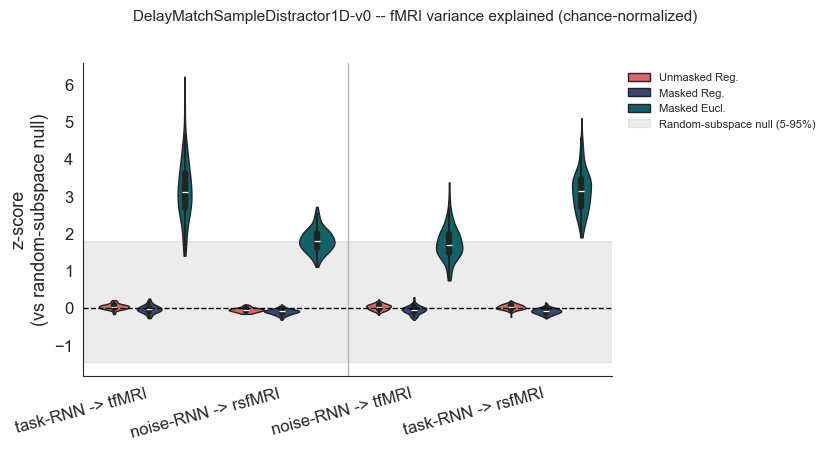

In [35]:
# Chance-normalized version of the fMRI variance-explained plot. Each approach
# is a single n_pc-dim RNN PC subspace predicting fMRI; we z-score its total
# variance explained (summed over PCs, averaged over learned runs) against a
# random n_pc-dim subspace null -- exactly the normalization used for the
# variance decomposition. z-scoring cancels the inter-subject baseline, so we
# work in raw VE units here.

# Per-subject null mean/SD per fMRI modality, pooling the two independent random
# subspaces (ve_t, ve_r) for a tighter estimate (both are random n_pc subspaces).
null_ve_stats = {}
for _mod in ('task', 'rest'):
    _nf = np.concatenate([null_decomp_full[_mod]['ve_t'],
                          null_decomp_full[_mod]['ve_r']], axis=1)   # (n_subj, 2*n_null)
    null_ve_stats[_mod] = {'mean': _nf.mean(axis=1),
                           'sd':   _nf.std(axis=1, ddof=1),
                           'full': _nf}

# Null band in z-space (per-subject standardized null, pooled across modalities).
_null_z_all = []
for _mod in ('task', 'rest'):
    _s = null_ve_stats[_mod]
    with np.errstate(divide='ignore', invalid='ignore'):
        _nz = (_s['full'] - _s['mean'][:, None]) / _s['sd'][:, None]
    _null_z_all.append(_nz[np.isfinite(_nz)].ravel())
_null_z_all = np.concatenate(_null_z_all)
null_z_lo, null_z_hi = np.percentile(_null_z_all, [5, 95])

# (variance-explained array, fMRI modality for the null, approach label)
approach_specs = [
    (fmri_task_variance_explained, 'task', 'task-RNN -> tfMRI'),
    (fmri_rest_variance_explained, 'rest', 'noise-RNN -> rsfMRI'),
    (fmri_task_ve_cross,           'task', 'noise-RNN -> tfMRI'),
    (fmri_rest_ve_cross,           'rest', 'task-RNN -> rsfMRI'),
]
approach_order = [a[2] for a in approach_specs]

records_ve_z = []
for task_idx in range(n_tasks):
    for model_idx in range(n_models):
        if model_params.task_no_modifier.iloc[model_idx] not in task_names[task_idx]:
            continue
        this_kernel = model_params.kernel_label.iloc[model_idx]
        learned_runs = test_accuracy_pca[model_idx] > 0.
        if (sum(learned_runs) / len(test_accuracy_pca[model_idx])) <= 0.1:
            continue
        for ve_arr, mod, alabel in approach_specs:
            # total VE = sum over PCs of the run-averaged per-PC variance explained
            raw_real = ve_arr[model_idx][:, :, learned_runs].mean(axis=2).sum(axis=0)
            nmean, nsd = null_ve_stats[mod]['mean'], null_ve_stats[mod]['sd']
            with np.errstate(divide='ignore', invalid='ignore'):
                z = (raw_real - nmean) / nsd
            for zz in z:
                records_ve_z.append({'task': task_names[task_idx],
                                     'kernel': this_kernel,
                                     'approach': alabel,
                                     'z': float(zz)})

df_ve_z = pd.DataFrame(records_ve_z)

set_font_size(13)
for task_idx in range(n_tasks):
    df_p = df_ve_z[df_ve_z['task'] == task_names[task_idx]]
    if df_p.empty:
        continue

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    sns.violinplot(data=df_p, x='approach', y='z', order=approach_order,
                   hue='kernel', hue_order=kernel_order, palette=color_palette_ve,
                   inner='box', linewidth=1, cut=0, dodge=True, ax=ax)

    ax.axhspan(null_z_lo, null_z_hi, color='gray', alpha=0.15, zorder=0,
               label='Random-subspace null (5-95%)')
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    # separator between the matched pair (first two) and the cross pair (last two)
    ax.axvline(1.5, color=[0.7, 0.7, 0.7], linewidth=1, zorder=0)

    ax.set_xlabel('')
    ax.set_ylabel('z-score\n(vs random-subspace null)')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False,
              fontsize=font_size - 3)

    fig.suptitle(f'{task_names[task_idx]} -- fMRI variance explained '
                 '(chance-normalized)', y=1.0, fontsize=11)
    sns.despine(fig=fig)
    fig.tight_layout()
    if save_figs:
        fig.savefig(os.path.join(outdir, f'fmri_ve_zscore_{task_names[task_idx]}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()


## Plot variance decomposition (unique-task / unique-rest / shared)

Per (task, fMRI modality, kernel), distributions across subjects of the three
partition components, averaged across learned runs and normalized by the
unified inter-subject baseline.


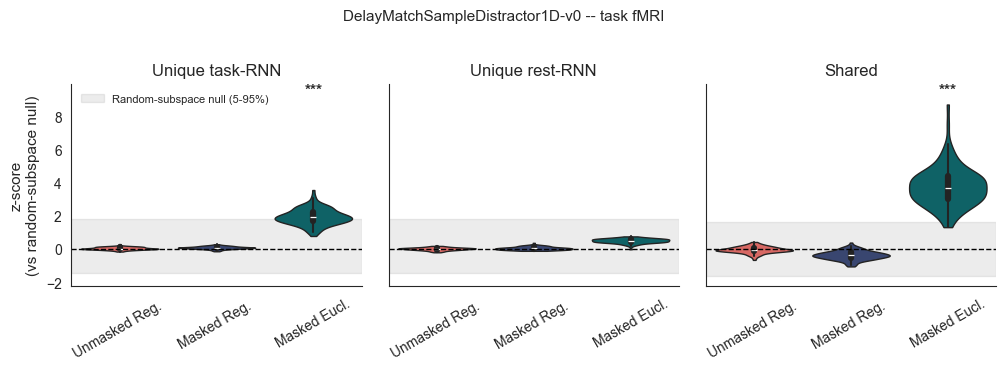

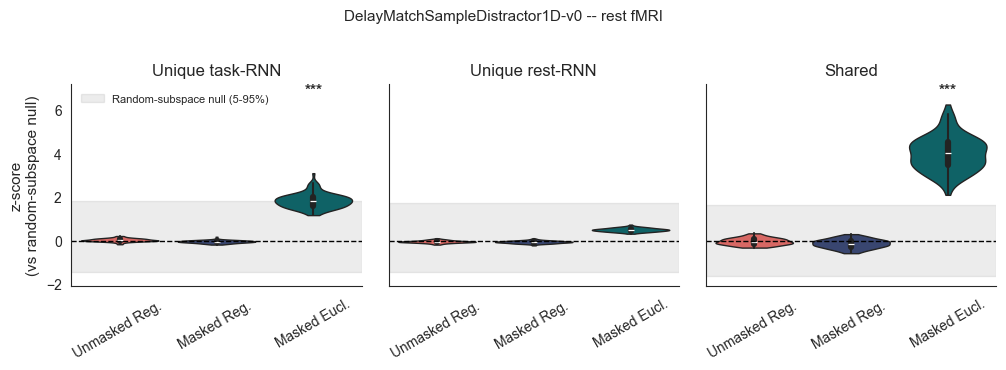

In [36]:
component_specs = [
    ('unique_t', 'Unique task-RNN'),
    ('unique_r', 'Unique rest-RNN'),
    ('shared',   'Shared'),
]
fmri_modalities = ['task', 'rest']

# Build long-form DataFrame for the variance partition (values are normalized
# by the unified inter-subject baseline, same as before).
records_decomp = []
for task_idx in range(n_tasks):
    for model_idx in range(n_models):
        if model_params.task_no_modifier.iloc[model_idx] not in task_names[task_idx]:
            continue
        this_kernel = model_params.kernel_label.iloc[model_idx]
        learned_runs = test_accuracy_pca[model_idx] > 0.
        learned_runs_frac = sum(learned_runs) / len(test_accuracy_pca[model_idx])
        if learned_runs_frac <= 0.1:
            continue
        for mod in fmri_modalities:
            data_mod = decomp_results[model_idx][mod]
            for comp_key, comp_label in component_specs:
                vals = (data_mod[comp_key][:, learned_runs]
                        .mean(axis=1) / fmri_intersubj_var_exp)
                for subj_idx_local, v in enumerate(vals):
                    records_decomp.append({
                        'kernel': this_kernel,
                        'task': task_names[task_idx],
                        'fmri_modality': mod,
                        'component': comp_label,
                        'subj_idx': subj_idx_local,
                        'value': float(v),
                    })

df_decomp = pd.DataFrame(records_decomp)

component_order = [lbl for _, lbl in component_specs]
component_key_by_label = {lbl: key for key, lbl in component_specs}
kernel_order = list(model_params.kernel_label.unique())

set_font_size(font_size)
for task_idx in range(n_tasks):
    for mod in fmri_modalities:
        df_p = df_decomp[(df_decomp['task'] == task_names[task_idx]) &
                         (df_decomp['fmri_modality'] == mod)]
        if df_p.empty:
            continue

        fig, axes = plt.subplots(1, len(component_order),
                                 figsize=(3.4 * len(component_order), 3.6),
                                 sharey=True, squeeze=False)

        # First pass: compute all z-scored data + null bands so we can set a
        # data-driven shared y-limit.
        panel_data = []
        for ci, comp in enumerate(component_order):
            comp_key = component_key_by_label[comp]

            # Per-subject null mean and SD (raw units; scaling cancels in z).
            null_full = null_decomp_full[mod][comp_key]   # (n_subj, n_null)
            null_mean_s = null_full.mean(axis=1)           # (n_subj,)
            null_sd_s = null_full.std(axis=1, ddof=1)      # (n_subj,)

            # Null distribution in z-space (per-subject standardization).
            with np.errstate(divide='ignore', invalid='ignore'):
                null_z = (null_full - null_mean_s[:, None]) / null_sd_s[:, None]
            null_z_finite = null_z[np.isfinite(null_z)]
            null_z_lo = float(np.percentile(null_z_finite, 5))
            null_z_hi = float(np.percentile(null_z_finite, 95))

            # z-score real values per subject (using raw real = normalized * baseline)
            df_c = df_p[df_p['component'] == comp].copy()
            real_raw = df_c['value'].values * fmri_intersubj_var_exp
            s_idx = df_c['subj_idx'].values.astype(int)
            with np.errstate(divide='ignore', invalid='ignore'):
                df_c['z'] = (real_raw - null_mean_s[s_idx]) / null_sd_s[s_idx]

            panel_data.append({
                'comp': comp, 'comp_key': comp_key, 'df_c': df_c,
                'null_z_lo': null_z_lo, 'null_z_hi': null_z_hi,
            })

        # Shared y-limits across panels (sharey=True is already on; set ranges)
        all_z = np.concatenate([p['df_c']['z'].dropna().values for p in panel_data])
        all_null_lo = min(p['null_z_lo'] for p in panel_data)
        all_null_hi = max(p['null_z_hi'] for p in panel_data)
        lo = min(float(np.nanmin(all_z)), all_null_lo, 0.0)
        hi = max(float(np.nanmax(all_z)), all_null_hi)
        span = max(hi - lo, 1e-6)

        for ci, pd_ci in enumerate(panel_data):
            ax = axes[0, ci]
            df_c = pd_ci['df_c']
            null_z_lo = pd_ci['null_z_lo']
            null_z_hi = pd_ci['null_z_hi']

            sns.violinplot(data=df_c, x='kernel', y='z', order=kernel_order,
                           hue='kernel', palette=color_palette_ve, legend=False,
                           inner='box', linewidth=1, cut=0, ax=ax)

            ax.set_ylim(lo - 0.06 * span, hi + 0.12 * span)

            ax.axhspan(null_z_lo, null_z_hi, color='gray', alpha=0.15, zorder=0,
                       label='Random-subspace null (5-95%)' if ci == 0 else None)
            ax.axhline(0, color='k', linestyle='--', linewidth=1)

            ax.set_title(pd_ci['comp'])
            ax.set_xlabel('')
            ax.tick_params(axis='x', rotation=30)
            if ci == 0:
                ax.set_ylabel('z-score\n(vs random-subspace null)')
                ax.legend(loc='upper left', fontsize=font_size-3, frameon=False)
            else:
                ax.set_ylabel('')

            # Significance gate: paired Wilcoxon (real > null, normalized units;
            # z-scoring is monotone so test outcome is unchanged) AND
            # median(z_real_kernel) > null_z_hi.
            null_per_subj_normalized = (null_decomp[mod][pd_ci['comp_key']]
                                        / fmri_intersubj_var_exp)
            text_y = hi + 0.04 * span
            for x_pos, kern in enumerate(kernel_order):
                df_k = df_c[df_c['kernel'] == kern].sort_values('subj_idx')
                real_vals = df_k['value'].values
                z_vals = df_k['z'].values
                if (real_vals.size == 0 or
                        real_vals.size != null_per_subj_normalized.size):
                    continue
                try:
                    _, p = stats.wilcoxon(real_vals, null_per_subj_normalized,
                                          alternative='greater')
                except ValueError:
                    p = np.nan
                if not (np.isfinite(p) and p < 0.05):
                    continue
                if float(np.nanmedian(z_vals)) <= null_z_hi:
                    continue
                star = sig_indicator(p)
                ax.text(x_pos, text_y, star, ha='center', va='bottom',
                        fontsize=font_size, fontweight='bold')

        fig.suptitle(f'{task_names[task_idx]} -- {mod} fMRI', y=1.02, fontsize=11)
        sns.despine(fig=fig)
        fig.tight_layout()
        if save_figs:
            fig.savefig(os.path.join(outdir,
                        f'fmri_ve_decomp_{mod}_{task_names[task_idx]}.svg'),
                        dpi=300, bbox_inches='tight', pad_inches=0.01)
        plt.show()


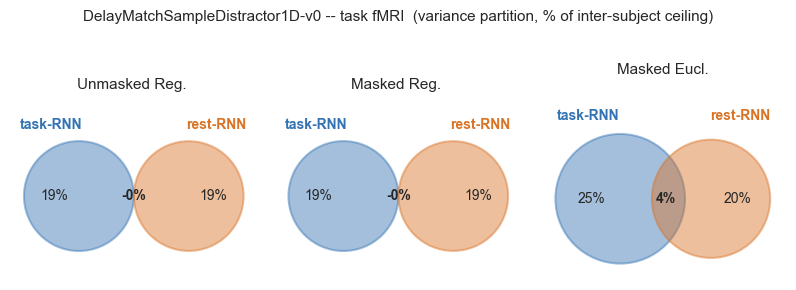

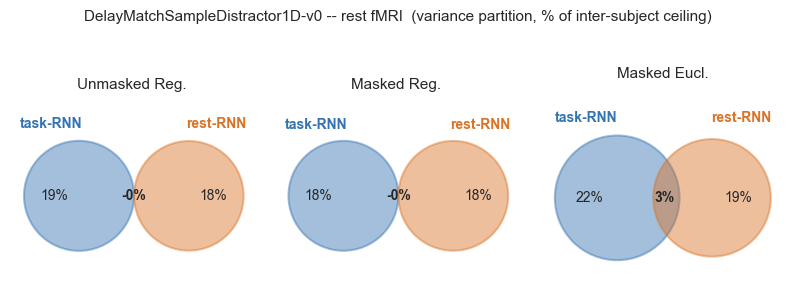

In [37]:
# Venn-diagram view of the variance partition (complements the violins above).
# Each two-circle Venn shows, for one kernel, how the fMRI variance captured by
# the task-RNN PC subspace (left circle) and the rest-RNN PC subspace (right
# circle) overlap. Areas are mean-across-subjects fractions normalized to the
# inter-subject ceiling -- the SAME `value` plotted in the violins, so the two
# figures are directly comparable:
#     |task-RNN circle| = unique_t + shared   (= ve_t / ceiling)
#     |rest-RNN circle| = unique_r + shared   (= ve_r / ceiling)
#     |overlap|         = shared
# Circles are area-proportional; the center distance is solved so the lens area
# equals `shared`. Negative/over-complete edge cases are clipped for geometry,
# but the true mean value is always annotated.

def _lens_area(d, r1, r2):
    """Area of the intersection (lens) of two circles, radii r1/r2, centers d apart."""
    if d >= r1 + r2:
        return 0.0
    if d <= abs(r1 - r2):
        return math.pi * min(r1, r2) ** 2
    d2 = d * d
    a1 = r1 * r1 * math.acos((d2 + r1 * r1 - r2 * r2) / (2 * d * r1))
    a2 = r2 * r2 * math.acos((d2 + r2 * r2 - r1 * r1) / (2 * d * r2))
    a3 = 0.5 * math.sqrt((-d + r1 + r2) * (d + r1 - r2) *
                         (d - r1 + r2) * (d + r1 + r2))
    return a1 + a2 - a3


def _solve_center_distance(r1, r2, target_overlap):
    """Center distance d giving a lens of area `target_overlap` (bisection)."""
    lo, hi = abs(r1 - r2), r1 + r2          # d in [|r1-r2| (contained), r1+r2 (disjoint)]
    if target_overlap >= math.pi * min(r1, r2) ** 2 - 1e-12:
        return lo
    if target_overlap <= 0.0:
        return hi
    for _ in range(100):                    # _lens_area is monotone-decreasing in d
        mid = 0.5 * (lo + hi)
        if _lens_area(mid, r1, r2) > target_overlap:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def draw_venn2(ax, area_t, area_r, area_shared, unique_t, unique_r, shared,
               colors, labels=('task-RNN', 'rest-RNN')):
    """Area-proportional two-circle Venn on `ax`. area_* drive geometry (clipped
    non-negative); unique_t/unique_r/shared are the raw means used for labels."""
    a = max(float(area_t), 0.0)
    b = max(float(area_r), 0.0)
    if a <= 0.0 and b <= 0.0:
        ax.text(0.5, 0.5, 'n/a', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return
    r1 = math.sqrt(a / math.pi) if a > 0 else 0.0
    r2 = math.sqrt(b / math.pi) if b > 0 else 0.0
    c = min(max(float(area_shared), 0.0), min(a, b))    # 0 <= overlap <= smaller circle
    d = _solve_center_distance(r1, r2, c) if (r1 > 0 and r2 > 0) else (r1 + r2)

    x1, x2 = -d / 2.0, d / 2.0
    ax.add_patch(plt.Circle((x1, 0.0), r1, facecolor=colors[0], edgecolor=colors[0],
                            alpha=0.45, lw=1.5, zorder=1))
    ax.add_patch(plt.Circle((x2, 0.0), r2, facecolor=colors[1], edgecolor=colors[1],
                            alpha=0.45, lw=1.5, zorder=1))

    rmax = max(r1, r2, 1e-3)
    pct = lambda v: f'{100 * v:.0f}%'
    # region value labels (in raw mean units, normalized to ceiling)
    if r1 > 0:
        ax.text(x1 - 0.45 * r1, 0.0, pct(unique_t), ha='center', va='center',
                fontsize=font_size - 1, zorder=3)
        ax.text(x1 - 0.5 * r1, rmax + 0.18 * rmax, labels[0], ha='center', va='bottom',
                fontsize=font_size - 1, color=colors[0], fontweight='bold')
    if r2 > 0:
        ax.text(x2 + 0.45 * r2, 0.0, pct(unique_r), ha='center', va='center',
                fontsize=font_size - 1, zorder=3)
        ax.text(x2 + 0.5 * r2, rmax + 0.18 * rmax, labels[1], ha='center', va='bottom',
                fontsize=font_size - 1, color=colors[1], fontweight='bold')
    ax.text(0.0, 0.0, pct(shared), ha='center', va='center',
            fontsize=font_size - 1, fontweight='bold', zorder=3)

    pad = 0.25 * rmax + 1e-3
    ax.set_xlim(x1 - r1 - pad, x2 + r2 + pad)
    ax.set_ylim(-rmax - pad, rmax + 0.55 * rmax + pad)
    ax.set_aspect('equal')
    ax.set_axis_off()


# Mean (across subjects, learned runs) of each partition component per group --
# reuses df_decomp, whose `value` already = component / fmri_intersubj_var_exp.
venn_agg = (df_decomp
            .groupby(['task', 'fmri_modality', 'kernel', 'component'])['value']
            .mean())
venn_colors = [(0.20, 0.45, 0.70), (0.85, 0.45, 0.15)]   # task-RNN, rest-RNN

set_font_size(11)
for task_idx in range(n_tasks):
    task = task_names[task_idx]
    for mod in fmri_modalities:
        present = [k for k in kernel_order
                   if (task, mod, k, 'Shared') in venn_agg.index]
        if not present:
            continue

        fig, axes = plt.subplots(1, len(present),
                                 figsize=(2.7 * len(present), 3.0),
                                 squeeze=False)
        for ci, kern in enumerate(present):
            ax = axes[0, ci]
            ut = float(venn_agg[(task, mod, kern, 'Unique task-RNN')])
            ur = float(venn_agg[(task, mod, kern, 'Unique rest-RNN')])
            sh = float(venn_agg[(task, mod, kern, 'Shared')])
            draw_venn2(ax, area_t=ut + sh, area_r=ur + sh, area_shared=sh,
                       unique_t=ut, unique_r=ur, shared=sh, colors=venn_colors)
            ax.set_title(kern, fontsize=font_size)

        fig.suptitle(f'{task} -- {mod} fMRI  (variance partition, '
                     '% of inter-subject ceiling)', y=1.02, fontsize=11)
        fig.tight_layout()
        if save_figs:
            fig.savefig(os.path.join(outdir,
                        f'fmri_ve_decomp_venn_{mod}_{task}.svg'),
                        dpi=300, bbox_inches='tight', pad_inches=0.01)
        plt.show()


## Weight-kernel similarity vs fMRI variance explained

In [38]:
# Weight-kernel similarity vs fMRI VE. Target = the *training* kernel (1 - K,
# off-diagonal), loaded with each model's own kernel_type / normalization so the
# readout mirrors exactly what the spatial loss optimized. Weight metric follows
# the loss: signed W for pearson / pearson_l2s; |W| only for the abs-correlation
# variants (pearson_abs*), whose objective is on connection magnitude.
_ABS_REG = {'pearson_abs', 'pearson_abs_l2s'}
_KERNEL_TYPES_WITH_EMBEDDING = {'euclidean', 'sf_axis', 'sa_axis', 'ut_axis'}

# Compute weight-kernel similarity and pair with fMRI variance explained
# (matched and cross-modal). All VE values are normalized by the unified
# inter-subject baseline (`fmri_intersubj_var_exp`).
records_wk = []

for model_idx in range(n_models):
    this = model_params.iloc[model_idx]
    kt = this.kernel_type

    # Skip models without a spatial kernel
    if kt not in _KERNEL_TYPES_WITH_EMBEDDING:
        continue

    # training-kernel similarity target (off-diagonal), matched to the loss
    K_train, _ = utils.load_embedding(kernel_type=kt, datadir=datadir,
                                      hidden_size=hidden_size,
                                      kernel_normalization=this.kernel_normalization)
    K_train = np.asarray(K_train)
    include_mask = ~np.eye(K_train.shape[0], dtype=np.bool_)
    target_vec = (1.0 - K_train)[include_mask]
    use_abs = this.reg_type in _ABS_REG

    learned_runs = test_accuracy_pca[model_idx] > -0.1  # currently not filtering out any runs

    for run_idx in range(len(trained_models_all[model_idx])):
        if not learned_runs[run_idx]:
            continue

        W_hh = trained_models_all[model_idx][run_idx]['rnn'].rnn.weight_hh_l0.detach().cpu().numpy()
        weight_vec = W_hh[include_mask]
        weight_metric = np.abs(weight_vec) if use_abs else weight_vec  # match the loss objective

        r_spearman, _ = stats.spearmanr(weight_metric, target_vec)
        eucl_dist = np.linalg.norm(weight_metric - target_vec)
        cos_sim = np.dot(weight_metric, target_vec) / (np.linalg.norm(weight_metric) * np.linalg.norm(target_vec))

        # Matched VE (RNN regime matches fMRI modality)
        fmri_task_ve = (fmri_task_variance_explained[model_idx][:, :, run_idx]
                        .sum(axis=0).mean() / fmri_intersubj_var_exp)
        fmri_rest_ve = (fmri_rest_variance_explained[model_idx][:, :, run_idx]
                        .sum(axis=0).mean() / fmri_intersubj_var_exp)
        # Cross-modal VE (RNN regime opposite to fMRI modality)
        fmri_task_ve_cross_val = (fmri_task_ve_cross[model_idx][:, :, run_idx]
                                  .sum(axis=0).mean() / fmri_intersubj_var_exp)
        fmri_rest_ve_cross_val = (fmri_rest_ve_cross[model_idx][:, :, run_idx]
                                  .sum(axis=0).mean() / fmri_intersubj_var_exp)

        task_perf = test_data_task[model_idx][run_idx]['accuracy']

        records_wk.append({
            'task': this.task_no_modifier,
            'kernel_label': this.kernel_label,
            'kernel_type': kt,
            'model_idx': model_idx,
            'run_idx': run_idx,
            'spearman': r_spearman,
            'euclidean': eucl_dist,
            'cosine': cos_sim,
            'fmri_task_var_exp': fmri_task_ve,
            'fmri_rest_var_exp': fmri_rest_ve,
            'fmri_task_var_exp_cross': fmri_task_ve_cross_val,
            'fmri_rest_var_exp_cross': fmri_rest_ve_cross_val,
            'accuracy': task_perf,
        })

df_wk = pd.DataFrame(records_wk)
print(f'{len(df_wk)} model-runs with spatial kernels')
df_wk.groupby(['task', 'kernel_label']).size()

100 model-runs with spatial kernels


task                             kernel_label
DelayMatchSampleDistractor1D-v0  Masked Eucl.    100
dtype: int64

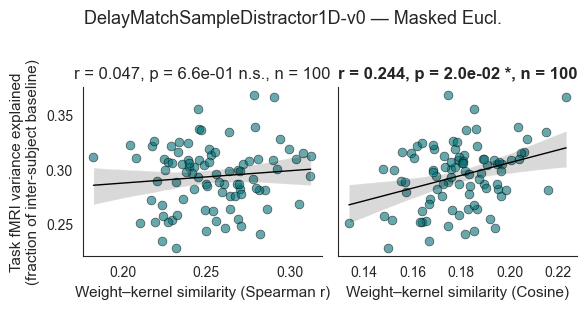

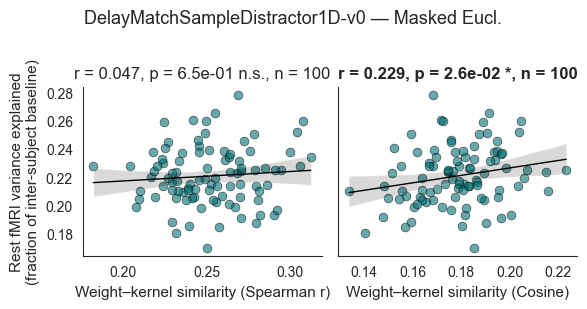

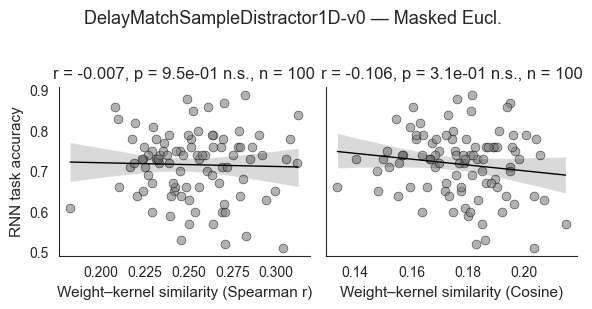

In [39]:
# Plot: one scatter per (task x kernel x metric), with regression line + CI and significance
plot_tasks = df_wk['task'].unique()
plot_kernels = df_wk['kernel_label'].unique()

metrics = {
    'spearman': 'Weight–kernel similarity (Spearman r)',
    # 'euclidean': 'Weight–kernel distance (Euclidean)',
    'cosine': 'Weight–kernel similarity (Cosine)',
}

font_size = 11
set_font_size(font_size)

my_colors = utils.get_my_colors(cat_trio=False, as_list=True)

plotting_y_metrics = [
    {
        'key': 'fmri_task_var_exp', 
        'ylabel': 'Task fMRI variance explained\n(fraction of inter-subject baseline)',
        'file_suff': '_weight_kernel_vs_fmri_task_ve',
        'color': my_colors[2] # [0.2, 0.4, 1.0]
        },
    {
        'key': 'fmri_rest_var_exp', 
        'ylabel': 'Rest fMRI variance explained\n(fraction of inter-subject baseline)',
        'file_suff': '_weight_kernel_vs_fmri_rest_ve',
        'color': my_colors[2] # [0.9, 0.2, 0.3]
        },
    {
        'key': 'accuracy', 
        'ylabel': 'RNN task accuracy',
        'file_suff': '_weight_kernel_vs_task_accuracy',
        'color': [0.5, 0.5, 0.5]
        }
]

for y_metric_idx in range(len(plotting_y_metrics)):
    
    y_metric_key = plotting_y_metrics[y_metric_idx]['key']
    y_metric_ylabel = plotting_y_metrics[y_metric_idx]['ylabel']
    y_metric_file_suff = plotting_y_metrics[y_metric_idx]['file_suff']
    y_metric_color = plotting_y_metrics[y_metric_idx]['color']
    
    
    for task in plot_tasks:
        
        # figw = 10
        # figh = figw / 4 * len(plot_kernels)
        # fig, axes = plt.subplots(nrows=len(plot_kernels), ncols=len(metrics), figsize=(figw,figh), 
        #                          squeeze=True, sharex=True, sharey=True)
        
        for kernel in plot_kernels:
            df_sub = df_wk[(df_wk['task'] == task) & (df_wk['kernel_label'] == kernel)]
            if len(df_sub) < 3:
                continue

            fig, axes = plt.subplots(1, len(metrics), figsize=(3*len(metrics), 3), sharey=True)
            axes = fig.axes
            ax_i = 0
            
            for ax, (metric, xlabel) in zip(axes, metrics.items()):
                x = df_sub[metric].values
                y = df_sub[y_metric_key].values
                
                x_mad = sp.stats.median_abs_deviation(x)
                y_mad = sp.stats.median_abs_deviation(y)
                x_modz = (x-np.median(x))/x_mad
                y_modz = (y-np.median(y))/y_mad
                modz_thr = 4
                excl = np.any(np.stack((x_modz < -modz_thr, 
                                        x_modz > modz_thr,
                                        y_modz < -modz_thr,
                                        y_modz > modz_thr)), 
                              axis=0)
                x = x[~excl]
                y = y[~excl]

                r, p = stats.spearmanr(x, y)

                # regression line with 95% CI via seaborn
                sns.regplot(x=x, y=y, ax=ax, scatter=True, color=y_metric_color, 
                            scatter_kws={'s': 40, 'alpha': 0.6, 'edgecolors':'k', 'linewidths': 0.5},
                            line_kws={'color': 'k', 'linewidth': 1},
                            ci=95)

                ax.set_xlabel(xlabel)
                if ax_i == 0:
                    ax.set_ylabel(y_metric_ylabel)
                # ax.set_ylim((0.05,0.4))
                sig = sig_indicator(p)
                title_str = f'r = {r:.3f}, p = {p:.1e} {sig}, n = {len(df_sub)}'
                ax.set_title(title_str, fontweight='bold' if sig != 'n.s.' else 'normal')
                
                ax_i += 1

            fig.suptitle(f'{task} — {kernel}', y=1.02)
            sns.despine(fig=fig, offset=0, trim=False)
            fig.tight_layout()

            if save_figs:
                fig.savefig(os.path.join(outdir, f'{task}_{kernel}_{y_metric_file_suff}.svg'),
                            dpi=600, bbox_inches='tight', pad_inches=0.01)

            plt.show()


## Subject-specific Euclidean similarity vs fMRI variance explained

For each Euclidean RNN, pair every (run, subject) with the cosine similarity between that run's hidden weights and that subject's Euclidean distance matrix (matched fMRI variance explained only). Two complementary questions:

- **Within-subject**: fixing a subject and varying the RNN run, does an RNN that is *more similar to this subject's* 1-D embedding better predict *this subject's* dynamics? (Spearman across runs, one value per subject.)
- **Between-subject**: fixing an RNN run and varying the subject, does the same RNN better predict the subjects it is *more similar to*? (Spearman across subjects, one value per run.)

Each distribution of correlations is tested against zero.

In [40]:
# Per-subject similarity targets (1 - normalized distance, matching cell 42 convention)
subj_target_sim = {sname: 1 - utils.normalize_x(eucl_dist_all[sname])
                   for sname in fmri_subjnames}

include_mask = ~np.eye(hidden_size, dtype=np.bool_)

# Weight metric follows the loss: |W| only for the abs-correlation variants;
# signed W for pearson / pearson_l2s. Cosine is computed on mean-centered vectors
# so it reflects *signed* alignment rather than an offset from the all-positive
# similarity (i.e. it matches Pearson in spirit); Spearman is rank-based so it is
# unaffected by the centering.
_ABS_REG = {'pearson_abs', 'pearson_abs_l2s'}

records_subj_wk = []
for model_idx in range(n_models):
    this = model_params.iloc[model_idx]
    if this.kernel_type != 'euclidean':
        continue
    use_abs = this.reg_type in _ABS_REG

    learned_runs = test_accuracy_pca[model_idx] > -0.1  # not filtering runs

    for run_idx in range(len(trained_models_all[model_idx])):
        if not learned_runs[run_idx]:
            continue

        W_hh = trained_models_all[model_idx][run_idx]['rnn'].rnn.weight_hh_l0.detach().cpu().numpy()
        weight_vec = W_hh[include_mask]
        weight_metric = np.abs(weight_vec) if use_abs else weight_vec
        wc = weight_metric - weight_metric.mean()
        wc_norm = np.linalg.norm(wc)

        for subj_idx, sname in enumerate(fmri_subjnames):
            target_vec = subj_target_sim[sname][include_mask]
            tc = target_vec - target_vec.mean()
            r_spearman, _ = stats.spearmanr(weight_metric, target_vec)
            cos_sim = np.dot(wc, tc) / (wc_norm * np.linalg.norm(tc))

            # Matched VE
            fmri_task_ve = (fmri_task_variance_explained[model_idx][:, subj_idx, run_idx].sum()
                            / fmri_intersubj_var_exp)
            fmri_rest_ve = (fmri_rest_variance_explained[model_idx][:, subj_idx, run_idx].sum()
                            / fmri_intersubj_var_exp)
            # Cross-modal VE
            fmri_task_ve_cross_val = (fmri_task_ve_cross[model_idx][:, subj_idx, run_idx].sum()
                                      / fmri_intersubj_var_exp)
            fmri_rest_ve_cross_val = (fmri_rest_ve_cross[model_idx][:, subj_idx, run_idx].sum()
                                      / fmri_intersubj_var_exp)

            records_subj_wk.append({
                'task': this.task_no_modifier,
                'kernel_label': this.kernel_label,
                'model_idx': model_idx,
                'run_idx': run_idx,
                'subject': sname,
                'subj_idx': subj_idx,
                'spearman': r_spearman,
                'cosine': cos_sim,
                'fmri_task_var_exp': fmri_task_ve,
                'fmri_rest_var_exp': fmri_rest_ve,
                'fmri_task_var_exp_cross': fmri_task_ve_cross_val,
                'fmri_rest_var_exp_cross': fmri_rest_ve_cross_val,
            })

df_subj_wk = pd.DataFrame(records_subj_wk)
print(f'{len(df_subj_wk)} (model, run, subject) rows for Euclidean RNNs')
df_subj_wk.head()

10000 (model, run, subject) rows for Euclidean RNNs


,task,kernel_label,model_idx,run_idx,subject,subj_idx,spearman,cosine,fmri_task_var_exp,fmri_rest_var_exp,fmri_task_var_exp_cross,fmri_rest_var_exp_cross
0,DelayMatchSampleDistractor1D-v0,Masked Eucl.,2,0,198350,0,0.263980,0.161978,0.325457,0.273425,0.313803,0.268019
1,DelayMatchSampleDistractor1D-v0,Masked Eucl.,2,0,871762,1,0.265372,0.166663,0.254843,0.267324,0.270562,0.265344
2,DelayMatchSampleDistractor1D-v0,Masked Eucl.,2,0,436239,2,0.264004,0.165539,0.375407,0.247407,0.368427,0.243617
3,DelayMatchSampleDistractor1D-v0,Masked Eucl.,2,0,200917,3,0.265479,0.164810,0.268350,0.280543,0.243402,0.273929
4,DelayMatchSampleDistractor1D-v0,Masked Eucl.,2,0,195041,4,0.262945,0.163623,0.274297,0.258420,0.293533,0.298130


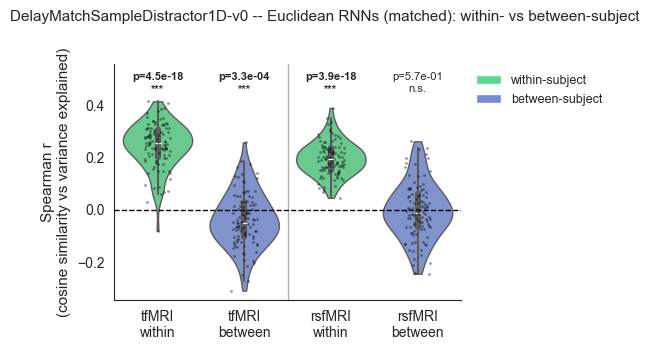

In [41]:
# Within- vs between-subject coupling between weight-kernel similarity (cosine)
# and matched fMRI variance explained, for both fMRI modalities.
#   within  : per subject, Spearman across RNN runs        (1 value / subject)
#   between : per RNN run, Spearman across subjects         (1 value / run)
plot_tasks_eu = df_subj_wk['task'].unique()

sim_key = 'cosine'
modalities = [('tfMRI', 'fmri_task_var_exp'),
              ('rsfMRI', 'fmri_rest_var_exp')]
min_runs_per_subj = 5     # min runs to estimate a within-subject correlation
min_subj_per_run  = 5     # min subjects to estimate a between-subject correlation

analysis_colors = {'within': (0.35, 0.85, 0.55), 'between': (0.45, 0.55, 0.85)}
# x-axis order: each modality gets a within / between pair
group_specs = []          # (group_label, modality_label, ve_key, analysis)
for mod_label, ve_key in modalities:
    group_specs.append((f'{mod_label}\nwithin',  mod_label, ve_key, 'within'))
    group_specs.append((f'{mod_label}\nbetween', mod_label, ve_key, 'between'))
order = [g for g, _, _, _ in group_specs]
palette = {g: analysis_colors[a] for g, _, _, a in group_specs}

set_font_size(11)
for task in plot_tasks_eu:
    df_task = df_subj_wk[df_subj_wk['task'] == task]

    group_vals = {g: [] for g in order}     # group label -> list of r values
    records_plot = []
    global_max, global_min = -np.inf, np.inf
    for grp, _mod, ve_key, analysis in group_specs:
        if analysis == 'within':
            grouper = df_task.groupby('subject')
            min_n = min_runs_per_subj
        else:
            grouper = df_task.groupby(['model_idx', 'run_idx'])
            min_n = min_subj_per_run
        for _key, df_g in grouper:
            if len(df_g) < min_n:
                continue
            r, _ = stats.spearmanr(df_g[sim_key].values, df_g[ve_key].values)
            if np.isfinite(r):
                group_vals[grp].append(r)
                records_plot.append({'group': grp, 'r': r})
                global_max = max(global_max, float(r))
                global_min = min(global_min, float(r))

    if not np.isfinite(global_max):
        continue

    data_span = max(global_max - global_min, 1e-6)
    ymax_axis = global_max + 0.20 * data_span
    ymin_axis = global_min - 0.05 * data_span
    text_y    = global_max + 0.04 * data_span

    fig, ax = plt.subplots(figsize=(6.0, 3.4))
    df_plot = pd.DataFrame(records_plot)
    sns.violinplot(data=df_plot, x='group', y='r', order=order,
                   hue='group', palette=palette, legend=False,
                   inner='box', linewidth=1, cut=0, ax=ax)
    sns.stripplot(data=df_plot, x='group', y='r', order=order,
                  ax=ax, color='k', size=2, alpha=0.4, jitter=0.15)
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_ylim(ymin_axis, ymax_axis)
    # separator between the two modality blocks
    ax.axvline(1.5, color=[0.7, 0.7, 0.7], linewidth=1, zorder=0)

    # Per-violin significance vs zero (two-sided Wilcoxon signed-rank).
    for x_pos, grp in enumerate(order):
        vals = np.array(group_vals[grp])
        if vals.size == 0 or np.allclose(vals, 0.0):
            continue
        try:
            _, p = stats.wilcoxon(vals)
        except ValueError:
            p = np.nan
        sig = sig_indicator(p) if np.isfinite(p) else 'n.s.'
        ax.text(x_pos, text_y, f'p={p:.1e}\n{sig}', ha='center', va='bottom',
                fontsize=font_size - 3,
                fontweight='bold' if sig != 'n.s.' else 'normal')

    ax.set_xlabel('')
    ax.set_ylabel(f'Spearman r\n({sim_key} similarity vs variance explained)')
    handles = [plt.matplotlib.patches.Patch(facecolor=analysis_colors['within'],
                                             label='within-subject'),
               plt.matplotlib.patches.Patch(facecolor=analysis_colors['between'],
                                             label='between-subject')]
    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1.0),
              frameon=False, fontsize=font_size - 2)

    fig.suptitle(f'{task} -- Euclidean RNNs (matched): '
                 'within- vs between-subject', y=1.02, fontsize=11)
    sns.despine(fig=fig, offset=0, trim=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'{task}_eucl_subj_within_between.svg'),
                    dpi=600, bbox_inches='tight', pad_inches=0.01)
    plt.show()


# Variance analysis


In [42]:
# set up weight masks
masks = get_weight_masks_schaefer(
    roi_names=list(pd.read_csv(eucl_kernel_file)[:hidden_size]['ROI Name']),
    input_system='Vis', output_system='Default')

kernel_types_var = model_params.kernel_type.unique().tolist()
kernel_labels_var = model_params.kernel_label.unique().tolist()
n_kernels_var = len(kernel_labels_var)

# define node groups to analyze
node_group_masks = {
    'input': masks['input_weight_mask'],
    'internal': masks['bystanders'],
    'output': masks['output_weight_mask']
}

# compute variance metrics across models for each task and node group
n_runs_var = min(len(test_data_task[m]) for m in range(n_models))
variance_by_task = {}

for task_idx in range(n_tasks):
    variance_by_group = {}
    for group_name, group_mask in node_group_masks.items():
        variance_by_group[group_name] = {
            'task_var': np.zeros((n_kernels_var, n_runs_var)),
            'temp_var': np.zeros((n_kernels_var, n_runs_var)),
            'spat_var': np.zeros((n_kernels_var, n_runs_var)),
            'mean_act': np.zeros((n_kernels_var, n_runs_var)),
        }

        for model_idx in tqdm(range(n_models), desc=f'Computing variance ({task_names[task_idx]}, {group_name} nodes)'):
            this = model_params.iloc[model_idx]
            if this.task_no_modifier not in task_names[task_idx]:
                continue
            k_idx = this.kernel_index

            for run in range(n_runs_var):
                ha = np.array(test_data_task[model_idx][run]['hidden_activity'])
                task_variance = compute_task_variance(hidden_activity=ha, mask=group_mask)
                variance_by_group[group_name]['task_var'][k_idx, run] = task_variance['hidden_activity_task_var'].mean()
                variance_by_group[group_name]['temp_var'][k_idx, run] = task_variance['hidden_activity_temp_var'].mean()
                variance_by_group[group_name]['spat_var'][k_idx, run] = task_variance['hidden_activity_spat_var'].mean()
                variance_by_group[group_name]['mean_act'][k_idx, run] = task_variance['hidden_activity_mean'].mean()

    variance_by_task[task_names[task_idx]] = variance_by_group

Computing variance (DelayMatchSampleDistractor1D-v0, input nodes): 100%|██████████| 3/3 [00:00<00:00, 16.54it/s]
Computing variance (DelayMatchSampleDistractor1D-v0, internal nodes): 100%|██████████| 3/3 [00:00<00:00,  6.10it/s]
Computing variance (DelayMatchSampleDistractor1D-v0, output nodes): 100%|██████████| 3/3 [00:00<00:00, 11.16it/s]



=== DelayMatchSampleDistractor1D-v0 — internal nodes ===


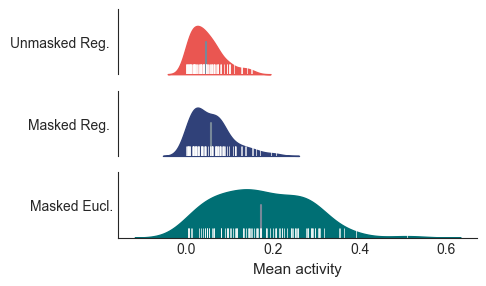

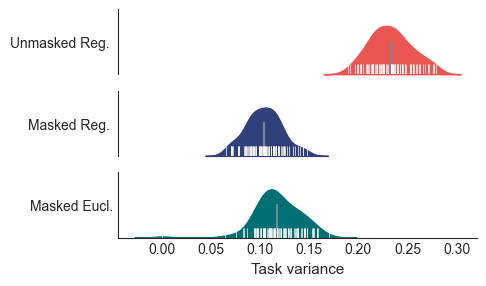

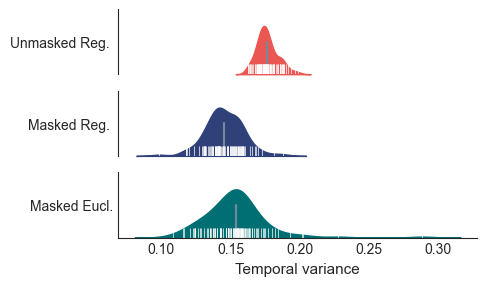

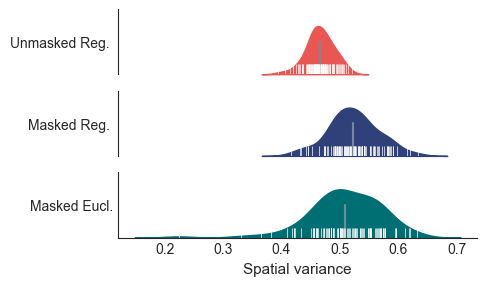

In [43]:
n_kernels_var = len(kernel_labels_var)
if n_kernels_var <= 3:
    color_palette_var = utils.get_my_colors(cat_trio=True, as_list=True)
else:
    color_palette_var = utils.get_my_colors(cat_trio=False, as_list=True)
# ensure we have enough colors
color_palette_var = color_palette_var[:n_kernels_var]

metric_keys = ['mean_act', 'task_var', 'temp_var', 'spat_var']
metric_labels = ['Mean activity', 'Task variance', 'Temporal variance', 'Spatial variance']

kernel_order_var = list(model_params.kernel_label.unique())

for task_idx in range(n_tasks):
    variance_by_group = variance_by_task[task_names[task_idx]]

    for group_name in ['internal']:  # node_group_masks:
        print(f'\n=== {task_names[task_idx]} — {group_name} nodes ===')

        for metric_key, label in zip(metric_keys, metric_labels):
            plot_data = variance_by_group[group_name][metric_key]
            if label == 'Mean activity':
                df = pd.DataFrame(data=np.abs(plot_data.T), columns=kernel_labels_var)
            else:
                df = pd.DataFrame(data=plot_data.T, columns=kernel_labels_var)
            df = pd.melt(df)
            df.columns = ['RNN', label]
            fig = categorical_kde_plot(df, variable=label, category="RNN",
                                       category_order=kernel_order_var,
                                       horizontal=1, color_palette=color_palette_var)

            fig.suptitle(f'{task_names[task_idx]} — {group_name} nodes', y=1.02, fontsize=10)
            if save_figs:
                fig.savefig(os.path.join(outdir, '{0}_{1}_node_{2}.svg'.format(
                    task_names[task_idx], group_name, label.replace(" ", "_"))),
                    dpi=600, bbox_inches='tight', pad_inches=0.01)

# Spatial null

## Fixed-initialization spin null (primary)

Single-init variant of the spin test: pick the **representative** euclidean run `R0` (task-VE-closest-to-mean) at `analysis_epoch`, then train the null ensemble with `null_run=R0`, `n_runs=1`, `null_perms=1000`. Init, recurrent noise and the training curriculum are held fixed across permutations, so the only thing that varies is the embedding geometry (σ_train = 0 by design). The cell below computes `R0`; put it into the null row of the model-params CSV, retrain the null ensemble, then score with `nu.fixed_init_spin_test`.

In [44]:
# --- Fixed-init spin null: pick the representative euclidean run R0 ---
# R0 = run whose task fMRI VE is closest to the cohort mean, scored with a FIXED test
# seed. Reuse this same seed when scoring the fixed-init null so the reference run and
# the permutations share the identical evaluation battery.
fixed_null_test_seed = 0   # any fixed int; must match the fixed-init scoring cell

# euclidean (signed pearson) real model among the loaded models
_eidx = model_params.index[(model_params['kernel_type'] == 'euclidean') &
                           (model_params['reg_type'] == 'pearson_l2s')].tolist()
assert _eidx, 'no euclidean (pearson_l2s) model in model_params'
eucl_idx = _eidx[0]

# per-run task/rest VE for the euclidean cohort at analysis_epoch (deterministic)
eucl_ve = nu.runs_fmri_ve(trained_models_all[eucl_idx], fmri_task_ts, fmri_rest_ts,
                          n_pc, n_trials=n_trials, rest_nsteps=fmri_rest_nsteps,
                          baseline=fmri_intersubj_var_exp, seed=fixed_null_test_seed)

R0 = nu.representative_run(eucl_ve['task'])
_t = eucl_ve['task']
print(f'euclidean cohort @ ~{analysis_epoch}: {len(_t)} runs  |  '
      f'task VE mean={_t.mean():.4f} sd={_t.std(ddof=1):.4f} '
      f'range=[{_t.min():.4f}, {_t.max():.4f}]')
print(f'\nrepresentative run  R0 = {R0}  '
      f'(task VE={_t[R0]:.4f}, |VE-mean|={abs(_t[R0]-_t.mean()):.4f}; '
      f"rest VE={eucl_ve['rest'][R0]:.4f})")
print(f'\n-> set the null row in the model-params CSV to: '
      f'n_runs=1, null_perms=1000, null_run={R0}  (euclidean / pearson_l2s)')

euclidean cohort @ ~39999: 100 runs  |  task VE mean=0.2935 sd=0.0369 range=[0.2040, 0.4228]

representative run  R0 = 81  (task VE=0.2936, |VE-mean|=0.0000; rest VE=0.2042)

-> set the null row in the model-params CSV to: n_runs=1, null_perms=1000, null_run=81  (euclidean / pearson_l2s)


In [45]:
# --- Fixed-init spin test: representative real run R0 vs the fixed-init null ensemble ---

# rows from the CSV: real euclidean reference (null_perms==0) and fixed-init null (null_run>0)
all_params, *_ = utils.get_params_dataframe(model_params_file, rows=[])
eucl_row = all_params[(all_params['kernel_type'] == 'euclidean') &
                      (all_params['reg_type'] == 'pearson_l2s') &
                      (all_params['null_perms'] == 0)].iloc[0]
fixed_null_row = all_params[(all_params['null_perms'] > 0) &
                            (all_params['null_run'] > 0)].iloc[0]
R0 = int(fixed_null_row['null_run'])

# completed perms (contiguous prefix): file present and run R0 trained to ~n_epochs
perm_rows = nu.make_null_rows(fixed_null_row)
thresh = 0.95 * int(fixed_null_row['n_epochs'])
n_avail = 0
for pr in perm_rows:
    fp = os.path.join(modeldir, pr['file_str_models'])
    eps = ModelStateManager(fp).get_run_epochs(R0) if os.path.isfile(fp) else []
    if not eps or max(eps) < thresh:
        break
    n_avail += 1
print(f'fixed-init perms complete: {n_avail}/{len(perm_rows)} (run {R0})')
assert n_avail > 0, 'no completed fixed-init perms yet -- train the null row first'

# score: real run R0 vs the n_avail permutations (identical fixed test battery)
fixed_init = nu.fixed_init_spin_test(
    eucl_row, fixed_null_row, fmri_task_ts, fmri_rest_ts, n_pc, modeldir, device,
    epoch=analysis_epoch, n_trials=n_trials, rest_nsteps=fmri_rest_nsteps,
    baseline=fmri_intersubj_var_exp, max_perms=n_avail, seed=fixed_null_test_seed)

for mod in ['task', 'rest']:
    r = fixed_init[mod]
    print(f'\n=== {mod} fMRI VE (fixed-init, run {R0} @ ~{fixed_init["real_epoch"]}) ===')
    print(f"  real={r['real']:.4f}  null mean={r['null_mean']:.4f} sd={r['null_std']:.4f}")
    print(f"  z={r['z']:.2f}  p={r['p']:.2e}  (real > {r['percentile']:.1f}% of {r['n_null']} perms)")

fixed-init perms complete: 200/200 (run 81)


/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/site-packages/gymnasium/envs/registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(
/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/site-packages/gymnasium/envs/registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(
/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.seed to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.seed` for environment variables or `env.get_wrapper_attr('seed')` that will search the reminding wrappers.
  logger.warn(
/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/site-packages/gymnasium/core.py:311: UserW


=== task fMRI VE (fixed-init, run 81 @ ~39999) ===
  real=0.2936  null mean=0.2481 sd=0.0327
  z=1.39  p=8.96e-02  (real > 91.5% of 200 perms)

=== rest fMRI VE (fixed-init, run 81 @ ~39999) ===
  real=0.2042  null mean=0.2087 sd=0.0219
  z=-0.21  p=5.72e-01  (real > 43.0% of 200 perms)


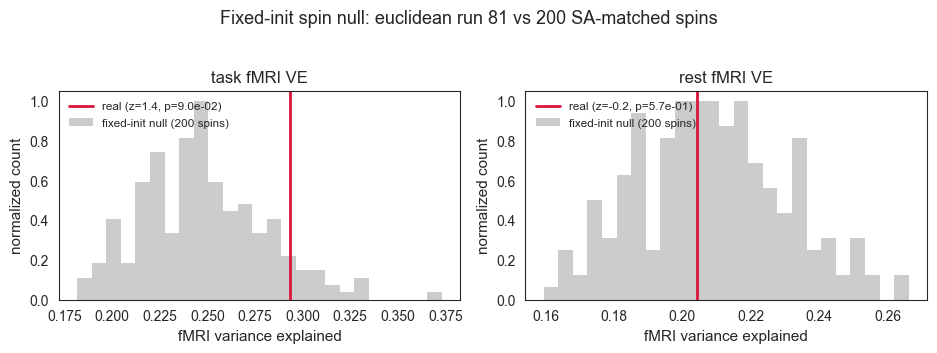

In [46]:
# fixed-init spin-null figure: null VE histogram + real run R0 + rank-based p
set_font_size(11)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for ax, mod in zip(axes, ['task', 'rest']):
    r = fixed_init[mod]
    nv = r['null_values']
    counts, edges = np.histogram(nv, bins=min(25, len(nv)))
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.bar(centers, counts / counts.max(), width=np.diff(edges),
           color='0.8', edgecolor='none', label=f'fixed-init null ({r["n_null"]} spins)')
    ax.axvline(r['real'], color='crimson', lw=2,
               label=f"real (z={r['z']:.1f}, p={r['p']:.1e})")
    ax.set_title(f'{mod} fMRI VE')
    ax.set_xlabel('fMRI variance explained'); ax.set_ylabel('normalized count')
    ax.legend(frameon=False, loc='upper left', fontsize=8.5)
fig.suptitle(f"Fixed-init spin null: euclidean run {fixed_init['run_index']} vs "
             f"{fixed_init['task']['n_null']} SA-matched spins", y=1.03)
fig.tight_layout()
if save_figs:
    fig.savefig(os.path.join(outdir, 'dynamics_spatial_null_fixedinit.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

## Size R for the mixed-effects null

Use the fixed-init run as a σ_geom probe. Its spins share run R0's training seeds,
so their spread is **pure geometry** (σ_geom). The real euclidean cohort's
run-to-run VE spread (same true geometry, different training) is **pure training
noise** (σ_train). Under a fixed N·R budget the optimal runs-per-permutation is
`R ≈ ρ = (σ_train/σ_geom)²`. Because the real cohort gives a *precise external*
σ_train, R=1 (max N) + deconvolution is the efficient alternative.

In [47]:
# sigma_geom = spin spread at fixed run R0 (fixed_init null_values, pure geometry)
# sigma_train = real euclidean cohort run-to-run VE spread (eucl_ve, pure training)
print(f'{"mod":>5} {"sigma_geom":>11} {"sigma_train":>12} {"rho":>7} '
      f'{"R~rho":>7} {"R (ext s_train)":>16}')
size_R = {}
for mod in ('task', 'rest'):
    s_geom  = float(np.std(fixed_init[mod]['null_values'], ddof=1))   # geometry spread
    s_train = float(np.std(eucl_ve[mod], ddof=1))                     # training spread
    rho = (s_train / s_geom) ** 2
    R_mixed = max(1, int(round(rho)))
    size_R[mod] = dict(sigma_geom=s_geom, sigma_train=s_train, rho=rho, R_mixed=R_mixed)
    print(f'{mod:>5} {s_geom:11.4f} {s_train:12.4f} {rho:7.2f} {R_mixed:>7} {"1":>16}')

# Precision-optimal R is round(rho), but the variance-components model needs R>=2
# to separate sigma_train internally (at R=1 every perm shares run 0's training ->
# it collapses to a fixed-init null and cannot deconvolve). So the feasible pick is:
R_rec = max(2, int(round(size_R['task']['rho'])))

print(f'\nsigma_geom from {fixed_init["task"]["n_null"]} fixed-init spins (run R0={fixed_init["run_index"]}); '
      f'sigma_train from {len(eucl_ve["task"])} real euclidean runs.')
print('\nGuidance (size for TASK -- the modality with the effect; rest for reference):')
print(f'  rho(task)={size_R["task"]["rho"]:.2f}  ->  precision-optimal R={max(1,int(round(size_R["task"]["rho"])))}, '
      f'but mixed model needs R>=2  ->  use R = {R_rec}, then N = budget // {R_rec}.')
print( '  R=1 would just re-do the fixed-init null (one training draw, no sigma_train split).')
print(f'  At R={R_rec} the flat N*R optimum costs only ~4% sigma_geom precision vs R=1, and')
print( '  R>=2 lets you cross-check the internal sigma_train against the external '
       f'{size_R["task"]["sigma_train"]:.4f} (homoscedasticity).')


  mod  sigma_geom  sigma_train     rho   R~rho  R (ext s_train)
 task      0.0327       0.0369    1.27       1                1
 rest      0.0219       0.0238    1.18       1                1

sigma_geom from 200 fixed-init spins (run R0=81); sigma_train from 100 real euclidean runs.

Guidance (size for TASK -- the modality with the effect; rest for reference):
  rho(task)=1.27  ->  precision-optimal R=1, but mixed model needs R>=2  ->  use R = 2, then N = budget // 2.
  R=1 would just re-do the fixed-init null (one training draw, no sigma_train split).
  At R=2 the flat N*R optimum costs only ~4% sigma_geom precision vs R=1, and
  R>=2 lets you cross-check the internal sigma_train against the external 0.0369 (homoscedasticity).


### Spanning run IDs for the mixed-effects null

Pick 5 real euclidean runs at balanced percentiles of the task VE (~10/30/50/70/90).
Their mean ≈ the cohort mean (so the real-vs-null comparison stays unbiased) and they
bracket the full training-outcome range — the principled generalization of the
fixed-init's single R0. Paste the printed list into the mixed-effects null row as
`null_run_ids` (space-separated); training then evaluates every spin geometry over
these same 5 draws (crossed perm×run design → run effect removable, σ_train internal).

In [48]:
# balanced percentiles -> nearest distinct real run per percentile
span_pct = [10, 30, 50, 70, 90]
_ve = np.asarray(eucl_ve['task'])
targets = np.percentile(_ve, span_pct)
chosen = []
for t in targets:
    for r in np.argsort(np.abs(_ve - t)):
        if int(r) not in chosen:
            chosen.append(int(r)); break
span_run_ids = sorted(chosen)

print(f'task-VE percentiles {span_pct} -> targets {np.round(targets, 4)}')
print(f'spanning run IDs : {span_run_ids}')
print(f'  their task VE  : {np.round(_ve[span_run_ids], 4)}')
print(f'  span mean VE   : {_ve[span_run_ids].mean():.4f}  (cohort mean {_ve.mean():.4f})')
print(f'  span sd VE     : {_ve[span_run_ids].std(ddof=1):.4f}  (cohort sd {_ve.std(ddof=1):.4f})')
print(f'  rest VE        : {np.round(np.asarray(eucl_ve["rest"])[span_run_ids], 4)}')
print(f'\n-> mixed-effects CSV row: n_runs={len(span_run_ids)}, '
      f'null_run_ids = "{" ".join(map(str, span_run_ids))}"')


task-VE percentiles [10, 30, 50, 70, 90] -> targets [0.2487 0.2762 0.2964 0.3081 0.3324]
spanning run IDs : [14, 24, 57, 68, 87]
  their task VE  : [0.3323 0.2489 0.3078 0.2963 0.2766]
  span mean VE   : 0.2924  (cohort mean 0.2935)
  span sd VE     : 0.0316  (cohort sd 0.0369)
  rest VE        : [0.222  0.218  0.2437 0.2314 0.2092]

-> mixed-effects CSV row: n_runs=5, null_run_ids = "14 24 57 68 87"


## Mixed-effects spin null (deconvolution, complementary)

Compare the real embedded model (signed pearson, euclidean) against the spin-permuted null ensemble on fMRI variance explained. A variance-components / mixed-effects model (`VE ~ 1 + (1|permutation)`) separates **training-run noise** from genuine **geometry-to-geometry spread**, so the real model is judged against the *geometry* distribution (headline test #1, outlier) rather than a noise-inflated null. The Wald contrast vs the permuted-population mean (#2) is reported alongside. Real and null use the identical metric at the matched `analysis_epoch`; the null row is excluded from the main model list, so this section is self-contained.

In [89]:
import importlib, src.null_utils
importlib.reload(src.null_utils)
from src import null_utils as nu      # rebind nu to the reloaded module

In [90]:
# real embedded model (signed pearson, euclidean) among the loaded models
_signed = model_params.index[(model_params['kernel_type'] == 'euclidean') &
                             (model_params['reg_type'] == 'pearson_l2s')].tolist()
assert _signed, 'no signed euclidean (pearson_l2s) model in model_params'
signed_idx = _signed[0]

# null row is excluded from the main model list; load it separately from the CSV
all_params, *_ = utils.get_params_dataframe(model_params_file, rows=[])
null_row = all_params[(all_params['null_perms'] > 0) &
                      (all_params['null_run'] == 0)].iloc[0]   # mixed-effects row (not fixed-init nr>0)
_nri = null_row['null_run_ids']
span_ids = sorted(int(x) for x in (_nri.split() if isinstance(_nri, str) else _nri))  # = column order
R = len(span_ids)
print(f"null: {int(null_row['null_perms'])} perms x {R} runs/perm  (spanning runs {span_ids})")

# per-run VE for the real model and the null ensemble (same metric, matched epoch)
# Fix the eval battery: identical task test-trials AND resting-state noise for every
# model (real and null), so run-to-run (sigma_train) spread reflects TRAINING
# variation, not test-noise variation -- essential for the noise-driven rest models.
# Same seed for real and null keeps the comparison apples-to-apples (cf. fixed-init).
null_test_seed = 0
real_ve = nu.runs_fmri_ve(trained_models_all[signed_idx], fmri_task_ts, fmri_rest_ts,
                          n_pc, n_trials=n_trials, rest_nsteps=fmri_rest_nsteps,
                          baseline=fmri_intersubj_var_exp, seed=null_test_seed)
null_ve = nu.compute_null_distribution(null_row, fmri_task_ts, fmri_rest_ts, n_pc,
                                       modeldir, device, epoch=analysis_epoch,
                                       n_trials=n_trials, rest_nsteps=fmri_rest_nsteps,
                                       baseline=fmri_intersubj_var_exp, seed=null_test_seed)

# keep only complete perms (all R runs present) so the crossed closed-form is balanced
keep = [i for i, rr in enumerate(null_ve['task_runs']) if len(rr) == R]
null_mat = {m: np.array([null_ve[f'{m}_runs'][i] for i in keep]) for m in ('task', 'rest')}

# Express VE as z vs the random orthonormal-subspace null (n_pc-dim). Raw VE scales
# with the number of PCs and is meaningless on its own, so we standardize to the
# random null (chance) -- the same normalization as the PCA-VE figures. This is a
# per-modality affine transform, so the outlier/Wald z and ICC are UNCHANGED; only
# the units change (chance -> 0). Requires the random-subspace null cell to have run.
assert 'null_decomp_full' in globals(), 'run the random orthonormal-subspace null cell first'
rand_null = {}
rand_chance_hi = {}
for _m in ('task', 'rest'):
    _r = np.concatenate([null_decomp_full[_m]['ve_t'].mean(0),
                         null_decomp_full[_m]['ve_r'].mean(0)])   # subj-avg raw VE per draw
    _mu, _sd = float(_r.mean()), float(_r.std(ddof=1))
    rand_null[_m] = (_mu, _sd)
    rand_chance_hi[_m] = float(np.percentile((_r - _mu) / _sd, 95))  # upper 95% of chance, z units
def _ve_to_z(ve, m):                          # ve is in /baseline units -> raw -> z
    mu, sd = rand_null[m]
    return (np.asarray(ve, float) * fmri_intersubj_var_exp - mu) / sd
real_ve = {m: (_ve_to_z(real_ve[m], m) if m in ('task', 'rest') else real_ve[m]) for m in real_ve}
null_mat = {m: _ve_to_z(null_mat[m], m) for m in ('task', 'rest')}

null_pm = {m: null_mat[m].mean(axis=1) for m in ('task', 'rest')}   # perm means (z units)
print(f"real: {len(real_ve['task'])} runs @ ~{analysis_epoch}   |   "
      f"null: {len(keep)}/{null_ve['n_perms']} complete perms @ {sorted(set(e for e in null_ve['epochs_used'] if e is not None))}")

# crossed mixed-effects test: VE ~ run + (1|perm). Removes the (deliberately
# spanning) run main effect so sigma_geom isn't deflated and sigma_train is the
# pure run x geometry residual.
null_mixed = {}
for mod in ['task', 'rest']:
    m = nu.mixed_null_test(null_mat[mod], real_ve[mod], n_boot=2000, crossed=True)
    null_mixed[mod] = m
    print(f"\n=== {mod} fMRI VE  (crossed: VE ~ run + (1|perm)) ===")
    print(f"  sigma_geom={m['sigma_geom']:.4f}  sigma_train(resid)={m['sigma_train']:.4f}  "
          f"sigma_run={m['sigma_run']:.4f}  ICC={m['icc']:.3f}")
    print(f"  #1 OUTLIER (vs geometry distribution): z={m['z_outlier']:.2f}  p={m['p_outlier']:.2e}")
    print(f"      95% CI: z {m['z_outlier_ci'][0]:.1f}-{m['z_outlier_ci'][1]:.1f}   "
          f"p {m['p_outlier_ci'][0]:.1e}-{m['p_outlier_ci'][1]:.1e}")
    print(f"  #2 Wald (vs permuted-population mean): z={m['z_wald']:.2f}  p={m['p_wald']:.2e}")
    print(f"  diagnostics: bootstrap frac sigma_geom<=0 = {m['boot_frac_geom_zero']:.2f}; "
          f"residual-normality p (geom/train) = {m['shapiro_geom_p']:.2f}/{m['shapiro_train_p']:.2f}")
    # homoscedasticity / transfer: do the null's run main effects match the real
    # model's VE at those same runs? (geometry-independent run effect -> valid)
    real_dev = np.asarray(real_ve[mod])[span_ids] - np.mean(real_ve[mod])
    r_transfer = np.corrcoef(m['run_effects'], real_dev)[0, 1]
    print(f"  run-effect transfer (null u_r vs real @ spanning runs): r={r_transfer:.2f}; "
          f"sigma_run(null)={m['sigma_run']:.4f} vs sigma_train(real cohort)={np.std(real_ve[mod], ddof=1):.4f}")
    if 'mixedlm_sigma_geom' in m:
        print(f"  MixedLM cross-check: sigma_geom={m['mixedlm_sigma_geom']:.4f}  "
              f"sigma_train={m['mixedlm_sigma_train']:.4f}")


null: 200 perms x 5 runs/perm  (spanning runs [14, 24, 32, 57, 87])


Exception ignored in: <function ResourceTracker.__del__ at 0x106678b80>
Traceback (most recent call last):
  File "/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104788b80>
Traceback (most recent call last):
  File "/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/ahmad/software/miniconda3/envs/neuro_rnn/lib/python3.12/multiprocessing/res

real: 100 runs @ ~39999   |   null: 200/200 complete perms @ [39999]

=== task fMRI VE  (crossed: VE ~ run + (1|perm)) ===
  sigma_geom=0.5714  sigma_train(resid)=1.5718  sigma_run=0.3129  ICC=0.117
  #1 OUTLIER (vs geometry distribution): z=3.67  p=1.23e-04
      95% CI: z 2.8-5.2   p 9.3e-08-2.9e-03
  #2 Wald (vs permuted-population mean): z=10.60  p=1.53e-26
  diagnostics: bootstrap frac sigma_geom<=0 = 0.00; residual-normality p (geom/train) = 0.11/0.36
  run-effect transfer (null u_r vs real @ spanning runs): r=0.06; sigma_run(null)=0.3129 vs sigma_train(real cohort)=1.8700
  MixedLM cross-check: sigma_geom=0.5714  sigma_train=1.5718

=== rest fMRI VE  (crossed: VE ~ run + (1|perm)) ===
  sigma_geom=0.2260  sigma_train(resid)=1.3109  sigma_run=0.2087  ICC=0.029
  #1 OUTLIER (vs geometry distribution): z=3.64  p=1.36e-04
      95% CI: z 1.7-12.7   p 1.7e-37-4.1e-02
  #2 Wald (vs permuted-population mean): z=5.57  p=1.27e-08
  diagnostics: bootstrap frac sigma_geom<=0 = 0.14; residu

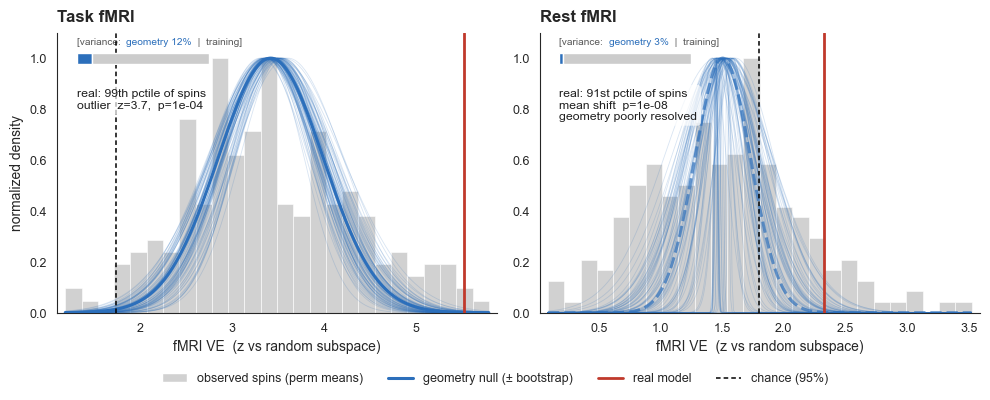

In [101]:
# Spatial-null figure (paper style). Anchor on the OBSERVED null (grey) + real
# line; the geometry (noise-removed) null is a bootstrap UNCERTAINTY band -- solid
# when sigma_geom is resolved, dashed when it is not. Data-driven verdict + a
# geometry/training variance-partition bar per panel.
from scipy.stats import norm as _norm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox
set_font_size(10)
BLUE, GREY, RED = '#2c6fbb', '0.82', '#c0392b'

def _ord(n):
    """1st, 2nd, 3rd, 4th, ... 11th, 21st, 92nd, ..."""
    n = int(round(n))
    suf = 'th' if 10 <= n % 100 <= 20 else {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f'{n}{suf}'

def _rich_label(ax, x, y, parts, fs=7.3):
    """Multi-colored one-line label at (x, y) axes-fraction. parts = [(text, color), ...]."""
    boxes = [TextArea(t, textprops=dict(color=c, fontsize=fs)) for t, c in parts]
    ax.add_artist(AnnotationBbox(HPacker(children=boxes, align='center', pad=0, sep=0),
                                 (x, y), xycoords='axes fraction', frameon=False,
                                 box_alignment=(0, 0.5)))

n_perm = len(null_pm['task'])
titles = {'task': 'Task fMRI', 'rest': 'Rest fMRI'}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
for ax, mod in zip(axes, ['task', 'rest']):
    m = null_mixed[mod]; pm = null_pm[mod]; real = m['real_mean']
    chance_hi = rand_chance_hi[mod]
    xs = np.linspace(min(pm.min(), real, chance_hi), max(pm.max(), real), 300); xf = xs[1] - xs[0]

    counts, edges = np.histogram(pm, bins=min(26, len(pm)))
    ax.bar(0.5 * (edges[:-1] + edges[1:]), counts / counts.max(), width=np.diff(edges),
           color=GREY, edgecolor='white', linewidth=0.4, zorder=1)

    bmu, bsg = m['boot_mu'], m['boot_sigma_geom']
    idx = np.linspace(0, len(bmu) - 1, min(80, len(bmu))).astype(int)
    for b in idx:
        g = _norm.pdf(xs, bmu[b], max(bsg[b], xf))
        ax.plot(xs, g / g.max(), color=BLUE, lw=0.6, alpha=0.18, zorder=2)
    resolved = m['boot_frac_geom_zero'] < 0.10
    g0 = _norm.pdf(xs, m['mu'], max(m['sigma_geom'], xf))
    ax.plot(xs, g0 / g0.max(), color=BLUE, lw=2.2, zorder=3,
            ls='-' if resolved else '--', alpha=1.0 if resolved else 0.7)
    ax.axvline(real, color=RED, lw=2, zorder=4)
    ax.axvline(chance_hi, color='k', lw=1.1, ls=(0, (3, 2)), zorder=3.5)   # random chance (95%); see legend

    ax.set_title(titles[mod], fontsize=12, loc='left', fontweight='bold', pad=8)
    ax.set_xlabel('fMRI VE  (z vs random subspace)'); ax.set_ylim(0, 1.1); ax.margins(x=0.02)
    sns.despine(ax=ax)

    # top-left: variance-partition bar with colored, bracketed label, then verdict
    bx = ax.inset_axes([0.045, 0.885, 0.30, 0.045])
    bx.barh([0], [m['icc']], color=BLUE)
    bx.barh([0], [1 - m['icc']], left=[m['icc']], color='0.80')
    bx.set_xlim(0, 1); bx.axis('off')
    _rich_label(ax, 0.045, 0.965,
                [('[variance:  ', '0.35'), (f"geometry {100 * m['icc']:.0f}%", BLUE),
                 ('  |  training]', '0.35')])
    pct = 100.0 * np.mean(pm < real)
    if resolved:
        v = f"real: {_ord(pct)} pctile of spins\noutlier  z={m['z_outlier']:.1f},  p={m['p_outlier']:.0e}"
    else:
        v = (f"real: {_ord(pct)} pctile of spins\nmean shift  p={m['p_wald']:.0e}\n"
             f"geometry poorly resolved")
    ax.text(0.045, 0.80, v, transform=ax.transAxes, va='top', fontsize=8.8, color='0.12', zorder=6,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.7))

axes[0].set_ylabel('normalized density')
handles = [Patch(fc=GREY, ec='white', label='observed spins (perm means)'),
           Line2D([0], [0], color=BLUE, lw=2.2, label='geometry null (± bootstrap)'),
           Line2D([0], [0], color=RED, lw=2, label='real model'),
           Line2D([0], [0], color='k', lw=1.1, ls=(0, (3, 2)), label='chance (95%)')]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=[0, 0.04, 1, 1])
if save_figs:
    fig.savefig(os.path.join(outdir, 'dynamics_spatial_null_mixed.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()


# INTs analysis


In [92]:
run_int_analysis = False 

## Compute ACF


In [93]:
if run_int_analysis:

    dynamic_keys = ['acw_50', 'acw_0', 'aca_50', 'aca_0']

    def compute_ac_one_model(model_task_data, model_rest_data, n_nodes, n_trials):
        n_runs = len(model_task_data)
        n_time_task = model_task_data[0]['hidden_activity'][0].shape[0]
        n_lags_task = n_time_task - 1
        n_lags_rest = 100

        ac_model_task = []
        ac_model_rest = []

        for run in range(n_runs):

            ac_run_task = {'ac': np.zeros((n_nodes, n_lags_task, n_trials))}
            for k in dynamic_keys:
                ac_run_task[k] = np.zeros((n_nodes, n_trials))

            ac_run_rest = {'ac': np.zeros((n_nodes, n_lags_rest))}
            for k in dynamic_keys:
                ac_run_rest[k] = np.zeros((n_nodes,))

            for node in range(n_nodes):
                for trial in range(n_trials):
                    ts = model_task_data[run]['hidden_activity'][trial][:, node]
                    ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_task)
                    ac_run_task['ac'][node, :, trial] = ac
                    ac_run_task['acw_50'][node, trial] = acw_50
                    ac_run_task['acw_0'][node, trial] = acw_0
                    ac_run_task['aca_50'][node, trial] = aca_50
                    ac_run_task['aca_0'][node, trial] = aca_0

                ts = model_rest_data[run]['hidden_activity'][:, node]
                ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_rest)
                ac_run_rest['ac'][node, :] = ac
                ac_run_rest['acw_50'][node] = acw_50
                ac_run_rest['acw_0'][node] = acw_0
                ac_run_rest['aca_50'][node] = aca_50
                ac_run_rest['aca_0'][node] = aca_0

            ac_model_task.append(ac_run_task)
            ac_model_rest.append(ac_run_rest)

        return ac_model_task, ac_model_rest


    with tqdm_joblib(tqdm(total=n_models), desc='Calculating AC'):
        results = Parallel(n_jobs=-1)(
            delayed(compute_ac_one_model)(
                test_data_task[model_idx],
                test_data_rest[model_idx],
                n_nodes,
                n_trials
            )
            for model_idx in range(n_models)
        )

    ac_data_task = [r[0] for r in results]
    ac_data_rest = [r[1] for r in results]

## Plot ACF


In [94]:
if run_int_analysis:
    
    size_scale = 2
    font_size = int(5 * size_scale)
    set_font_size(font_size)
    n_fig_columns = min((3, n_tasks))
    n_fig_rows = math.ceil(n_tasks / n_fig_columns)
    fig_size_w = 2.5 * n_fig_columns * size_scale
    fig_size_h = 2 * n_fig_rows * size_scale

    plotting_data = [
        [ac_data_task, 'task'],
        [ac_data_rest, 'rest']
    ]

    n_runs_plot = n_runs

    for i in range(len(plotting_data)):
        for kernel_idx in range(n_kernels):

            f_ac, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                                squeeze=True, sharex=True, sharey=True)

            for model_idx in range(n_models):
                if model_params.loc[model_idx, 'kernel_index'] == kernel_idx:
                    task_index = model_params.loc[model_idx, 'task_index']
                    n_runs_plot = min(n_runs_plot, len(test_data_task[model_idx]))

                    f_ac.axes[task_index].axhline(y=0, color='k', linewidth=1.)

                    this_data = plotting_data[i][0]
                    n_lags = this_data[model_idx][0]['ac'].shape[1]
                    y_plot = np.zeros((n_nodes, n_lags, n_runs_plot))

                    for run in range(n_runs_plot):
                        run_data = this_data[model_idx][run]['ac']
                        if run_data.ndim == 3:
                            y_plot[:, :, run] = np.nanmean(run_data, axis=2)
                        else:
                            y_plot[:, :, run] = run_data

                    y_plot = np.squeeze(np.nanmean(y_plot, axis=2))

                    for node in range(n_nodes):
                        f_ac.axes[task_index].plot(y_plot[node, :], color=colors[node, :],
                                                linewidth=0.5, alpha=1)
                    f_ac.axes[task_index].set_title(model_params.loc[model_idx, 'task_label'])

            f_ac.axes[0].set_ylim((-1, 1))
            f_ac.suptitle(kernel_labels[kernel_idx] + ' (' + plotting_data[i][1] + ')')
            sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
            f_ac.tight_layout()
            plt.show()

            if save_figs:
                suff = '{:}_{:}'.format(task_names[0], model_params.rnn_model.iloc[0])
                f_ac.savefig(os.path.join(outdir, 'acf_{:}_masks-{:}_{:}_{:}.svg'.format(
                    suff, model_params.mask_weights.iloc[kernel_idx],
                    plotting_data[i][1], model_params.kernel_type.iloc[kernel_idx])),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)


## ACW and ACA violin plots


In [95]:
if run_int_analysis:
        
    plotting_data_acw = [
        [ac_data_rest, 'rest']
    ]
    plotting_keys = ['acw_0'] # ['acw_50', 'acw_0', 'aca_50', 'aca_0']

    size_scale = 5
    font_size = int(5 * size_scale)
    set_font_size(font_size)
    n_fig_columns = min((3, n_tasks))
    n_fig_rows = math.ceil(n_tasks / n_fig_columns)
    fig_size_w = 5 * n_fig_columns * size_scale
    fig_size_h = 2 * n_fig_rows * size_scale

    for i in range(len(plotting_data_acw)):
        for j in range(len(plotting_keys)):

            f_ac, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                                squeeze=True, sharex=True, sharey=False)

            for task_index in range(n_tasks):

                this_task_models = model_params[model_params['task_index'] == task_index]
                plotting_df = pd.DataFrame()
                ax = f_ac.axes[task_index]

                for model_idx in range(len(this_task_models)):

                    this_model_data = plotting_data_acw[i][0][this_task_models.iloc[model_idx].model_index]
                    this_model_kernel = this_task_models.iloc[model_idx].kernel_label
                    this_model_task = this_task_models.iloc[model_idx].task_label

                    y_plot = np.zeros((n_nodes, len(this_model_data)))
                    n_runs_here = len(this_model_data)
                    for run in range(n_runs_here):
                        run_data = this_model_data[run][plotting_keys[j]]
                        if run_data.ndim == 2:
                            y_plot[:, run] = run_data.mean(axis=1)
                        else:
                            y_plot[:, run] = run_data

                    y_plot = np.squeeze(y_plot.mean(axis=1))

                    this_plotting_df = pd.DataFrame({
                        'y': y_plot,
                        'task': this_model_task,
                        'kernel': np.repeat(this_model_kernel, n_nodes),
                        'node_group': node_groups_labels
                    })
                    plotting_df = pd.concat([plotting_df, this_plotting_df], ignore_index=True)

                # create violin plot
                hue_order = ['in', 'inter', 'out']
                palette = dict(zip(hue_order, np.flip(colors_categ, axis=0)))
                sns.violinplot(x='kernel', y='y', hue='node_group', data=plotting_df,
                            linewidth=1, cut=0, saturation=1, inner='box', dodge=True,
                            palette=palette, hue_order=hue_order, order=kernel_labels,
                            ax=ax)
                ax.set_xlabel('')
                ax.set_ylabel('')
                ax.set_title(task_names[task_index])
                for x in ax.get_xticks()[:-1]+0.5: 
                    ax.axvline(x=x, color=[0.7]*3)
                plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

            f_ac.suptitle(plotting_keys[j] + ' (' + plotting_data_acw[i][1] + ')')
            sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
            f_ac.tight_layout()
            plt.show()


## fMRI AC and INTs

In [96]:
if run_int_analysis:

    ac_data_fmri = []
    dynamic_keys = ['acw_0'] # ['acw_50','acw_0','aca_50','aca_0']
    n_lags_rest = 100

    for subj in tqdm(range(n_fmri_subj), desc='Computing AC for fMRI'):
            
            # initialize arrays of AC, ACW, and ACA values for this subject
            ac_subj_rest = dict()
            ac_subj_rest['ac'] = np.zeros((n_nodes,n_lags_rest,))
            for k in dynamic_keys:
                ac_subj_rest[k] = np.zeros((n_nodes,))
            
            # nodes loop
            for node in range(n_nodes):
                
                # get values for rest
                ts = fmri_rest_ts[:,node,subj]
                ac, acw_50, acw_0, aca_50, aca_0 = compute_ac_acw_aca(ts, nlags=n_lags_rest)
                ac_subj_rest['ac'][node,:] = ac
                for k in dynamic_keys:
                    ac_subj_rest[k][node] = globals()[k]
            
            # append this subject's data 
            ac_data_fmri.append(ac_subj_rest)

In [97]:
if run_int_analysis:
    plotting_keys_fmri = ['acw_0']  # ['acw_50', 'acw_0', 'aca_50', 'aca_0']

    size_scale = 1.5
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    n_fig_columns = 1
    n_fig_rows = 1
    fig_size_w = 4 * n_fig_columns * size_scale
    fig_size_h = 2 * n_fig_rows * size_scale

    for j in range(len(plotting_keys_fmri)):

        f_ac, ax = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                                squeeze=True)

        plotting_df = pd.DataFrame()

        for subj in range(n_fmri_subj):
            subj_data = ac_data_fmri[subj]

            y_plot = subj_data[plotting_keys_fmri[j]]
            if y_plot.ndim == 2:
                y_plot = y_plot.mean(axis=1)
            y_plot = np.squeeze(y_plot)

            this_plotting_df = pd.DataFrame({
                'y': y_plot,
                'subject': np.repeat(subj, n_nodes),
                'kernel': np.repeat('fMRI', n_nodes),
                'node_group': node_groups_labels
            })
            plotting_df = pd.concat([plotting_df, this_plotting_df], ignore_index=True)

        # average across subjects per node, then build a single-row df
        plotting_df = plotting_df.groupby(['kernel', 'node_group'], sort=False).agg({'y': 'mean'}).reset_index()
        # re-expand: one row per node with mean across subjects
        mean_per_node = np.mean([ac_data_fmri[s][plotting_keys_fmri[j]] for s in range(n_fmri_subj)], axis=0)
        plotting_df = pd.DataFrame({
            'y': mean_per_node,
            'kernel': np.repeat('fMRI', n_nodes),
            'node_group': node_groups_labels
        })

        # create violin plot
        hue_order = ['in', 'inter', 'out']
        palette = dict(zip(hue_order, np.flip(colors_categ, axis=0)))
        sns.violinplot(x='kernel', y='y', hue='node_group', data=plotting_df,
                    linewidth=1, cut=0, saturation=1, inner='box', dodge=True,
                    palette=palette, hue_order=hue_order,
                    ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('fMRI')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

        f_ac.suptitle(plotting_keys_fmri[j] + ' (fMRI)')
        sns.despine(fig=f_ac, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
        f_ac.tight_layout()
        plt.show()


## Correlation between fMRI and RNN INTs

In [98]:
if run_int_analysis:
        
    int_keys = ['acw_0']  # extend as needed: ['acw_0', 'aca_0', 'acw_50', 'aca_50']
    node_selection = np.isin(node_groups, [1,]) # <<<<< select nodes here
    font_size = 12
    set_font_size(font_size)

    # Compute mean fMRI INT per node (average across subjects)
    fmri_mean = {}
    for key in int_keys:
        fmri_mean[key] = np.mean([ac_data_fmri[s][key] for s in range(n_fmri_subj)], axis=0)[node_selection]

    # Compute mean RNN INT per node per model (average across runs)
    rnn_mean = {}
    for key in int_keys:
        rnn_mean[key] = []
        for model_idx in range(n_models):
            runs = ac_data_rest[model_idx]
            model_avg = np.mean([run[key] for run in runs], axis=0)[node_selection]
            rnn_mean[key].append(model_avg)

    # Plot: one figure per INT key, one subplot per model
    for key in int_keys:
        fig, axes = plt.subplots(n_models, 1, figsize=(5, n_models * 5 ), 
                                squeeze=False, sharex=False, sharey=True)
        axes = axes.ravel()

        for model_idx in range(n_models):
            ax = axes[model_idx]
            x = rnn_mean[key][model_idx]
            y = fmri_mean[key]

            r, p = stats.spearmanr(x, y)

            ax.scatter(x, y, c=colors[node_selection], s=50, alpha=1.0, edgecolors='k')
            # fit and plot regression line
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1)

            ax.set_xlabel(f'RNN {key}')
            ax.set_ylabel(f'fMRI {key}')
            title = f"{model_params.loc[model_idx, 'task_label']} | {model_params.loc[model_idx, 'kernel_label']}"
            ax.set_title(f'{title}\nr={r:.3f}, p={p:.1e}')

        fig.suptitle(f'Node-level {key}: fMRI vs RNN', y=1.02)
        sns.despine(fig=fig, offset=0, trim=False)
        fig.tight_layout()
        plt.show()

In [99]:
if run_int_analysis:
        
    int_keys = ['acw_0']  # extend as needed: ['acw_0', 'aca_0', 'acw_50', 'aca_50']
    set_font_size()

    n_kernels_corr = len(kernel_labels)
    if n_kernels_corr <= 3:
        color_palette_corr = utils.get_my_colors(cat_trio=True, as_list=True)
    else:
        color_palette_corr = utils.get_my_colors(cat_trio=False, as_list=True)
    color_palette_corr = color_palette_corr[:n_kernels_corr]

    kernel_order = list(model_params.kernel_label.unique())

    for key in int_keys:
        records = []
        for model_idx in range(n_models):
            this_kernel = model_params.loc[model_idx, 'kernel_label']
            this_task = model_params.loc[model_idx, 'task']
            for run_data in ac_data_rest[model_idx]:
                rnn_vals = run_data[key]
                run_records = []
                for subj in range(n_fmri_subj):
                    fmri_vals = ac_data_fmri[subj][key]
                    mask_valid = ~np.isnan(rnn_vals) & ~np.isnan(fmri_vals)
                    if mask_valid.sum() > 2:
                        r, _ = stats.spearmanr(rnn_vals[mask_valid], fmri_vals[mask_valid])
                    else:
                        r = np.nan
                    run_records.append(r)
                run_records = np.array(run_records)
                records.append({'kernel': this_kernel, 'task': this_task, 'corr': np.median(run_records)})

        df_corr = pd.DataFrame(records).dropna(subset=['corr'])

        for task_idx in range(n_tasks):
            df_task = df_corr[df_corr['task'] == task_names[task_idx]]
            fig = categorical_kde_plot(df_task, variable='corr', category='kernel',
                                    category_order=kernel_order, horizontal=1,
                                    color_palette=color_palette_corr,
                                    title=f'{task_names[task_idx]} — {key} (Spearman r)',
                                    rug=1, refline=0, ttest=True)